# Does Codex change GPT-4o-mini when the reader payload is the same?

Six cells answer LoCoMo from the same rendered `qa_mem0_v1` payload. Two memory texts are compared: stuffed full context, and the dataset session summaries. Each text is read by GPT-4o-mini Chat Completions, by Codex with persistence off, and by Codex with persistence on.

The question is whether the harness changes answer quality once the memory text and the question are held fixed, and whether `memory/notes.md` explains the split between Mem0 judge score and LoCoMo F1.


## Glossary

| Term | Meaning |
|---|---|
| Reference answer | The LoCoMo gold string. Scorers see it. The reader prompt does not. Category 3 uses the text before the first semicolon. Category 5 is empty on 444 of 446 questions. |
| Gold stems | Content words of that reference answer after LoCoMo normalization (lowercase, punctuation and a/an/the/and removed) and Porter stemming. They are properties of the reference answer. A gold stem may be in the memory text, in the answer, in both, or in neither. |
| Memory recall | Share of gold stems that appear in the memory text. |
| Answer recall | Share of gold stems that appear in the answer. This is the fact-finding rate. |
| Answer precision | Share of the answer's stems that are gold stems. Extra words lower it even when the gold stems are still there. |
| Kept given memory | Of the gold stems that were in the memory text, the share that also appear in the answer. |
| Dropped given memory | Of those same in-memory gold stems, the share the answer omits. On each such question it is 1 minus kept. The table includes it. There is no separate plot. |
| LoCoMo F1 | Token overlap with the reference answer. Category 5 is 1 only when the answer contains `not mentioned` or `no information available`. |
| Judge score | Mem0 CORRECT/WRONG on the same predicted string. Category 5 is skipped and stored as 0. That 0 is a placeholder. |
| Refusal phrase | Those two LoCoMo substrings. It is a narrow proxy for abstention. `No mention of painting` is the same decision and scores 0. |
| Adversarial refusal | Refusal-phrase rate on category 5. |
| False refusal | Refusal-phrase rate on categories 1-4. |
| Persist-off | Codex receives the rendered reader payload and nothing after it. |
| Persist-on | The same payload, plus a harness note footer. Codex may read and append `memory/notes.md`. |
| Reader list price | Pinned GPT-4o-mini USD for that question's recorded input and output tokens. The judge is not included. Not an invoice. |


## Method

The matrix is `configs/experiments/openai_mini_codex_readers_analysis.yaml`, collected as `locomo-openai-mini-codex-readers-analysis-v2`. Web search and user MCP are disabled. The workspace has no session files. Evidence is in the task prompt (`prompt_injected`), so a missing workspace read is not a retrieval failure.

Persist-off Codex and the model share `reader_payload_sha256`. Persist-on appends the note footer, so `agent_task_sha256` differs. Overall judge score and LoCoMo F1 below drop category 5, matching Mem0. Category plots keep it.

The pre-test states the six-cell design before the tables. The post-test checks the finished pack against that design. Later sections display one analysis at a time from that report.


## Pre-test — GPT-4o-mini and Codex reader analysis

All six cells render qa_mem0_v1 with the same memory text and question. Model-only and Codex persist-off share that payload exactly. Codex persist-on appends a harness-only note instruction and may reuse evidence-grounded notes; payload and final-task hashes stay separate. Prompt-delivered evidence is not workspace retrieval. Web search and user MCP are disabled or ignored and must remain zero in audit metrics.

Config: `C:/home/research/Distillation/distillation/configs/analysis/campaign_openai_mini_codex_readers_analysis.yaml`

### `readers` — `locomo-openai-mini-codex-readers-analysis-v2`
- **not a scientific claim**
- expected cells: **6**
- hypothesis: Two GPT-4o-mini one-shot reader cells use full context or dataset summaries.
- hypothesis: Persist-off Codex receives the matching rendered reader payload.
- hypothesis: Persist-on Codex uses the same payload plus an audited notes instruction.


_No `cost:` block in this campaign YAML._

Output `C:/home/research/Distillation/distillation/experiments/_campaign/openai_mini_codex_readers_analysis/analysis`

## Takeaways — harness vs model reader/writer

table: `C:/home/research/Distillation/distillation/experiments/_campaign/openai_mini_codex_readers_analysis/analysis/tables/takeaways.csv`

### Full context — model vs Codex
claim: `full_context_harness_delta`

The model and persist-off Codex receive the same rendered reader payload. The remaining difference is Chat Completions versus Codex orchestration.

...

### Session summaries — model vs Codex
claim: `summaries_harness_delta`

The LoCoMo summaries and question are identical reader payloads before either system answers.

left_label,right_label,metric,n_left,n_right,left_value,right_value,delta
model_session_summaries,codex_session_summaries_persist_off,judge_score,1540,1540,0.4883,0.4903,-0.0019
model_session_summaries,codex_session_summaries_persist_off,locomo_f1,1540,1540,0.3441,0.314,0.0301


### Persisted Codex is a stateful reader condition
claim: `persisted_agent_state`

Persist-on adds an explicitly logged Codex note instruction after the shared reader payload. It is an auditable stateful-agent condition, not exact end-to-end request parity.

### Matched reader payload conditions

memory_method,prompt_parity_condition,n,judge_score,locomo_f1,token_f1,exact_match,answer_n_words
full_context,4o-mini,1540,0.7474,0.5383,0.5319,0.211,4.0994
full_context,4o-mini + Codex (persist off),1540,0.7409,0.4382,0.4336,0.1188,6.3721
full_context,4o-mini + Codex (persist on),1540,0.7636,0.3367,0.3304,0.0338,14.1221
session_summaries,4o-mini,1540,0.4883,0.3441,0.3359,0.1143,4.013
session_summaries,4o-mini + Codex (persist off),1540,0.4903,0.314,0.308,0.0883,5.1442
session_summaries,4o-mini + Codex (persist on),1540,0.5149,0.2407,0.2344,0.0234,9.2844


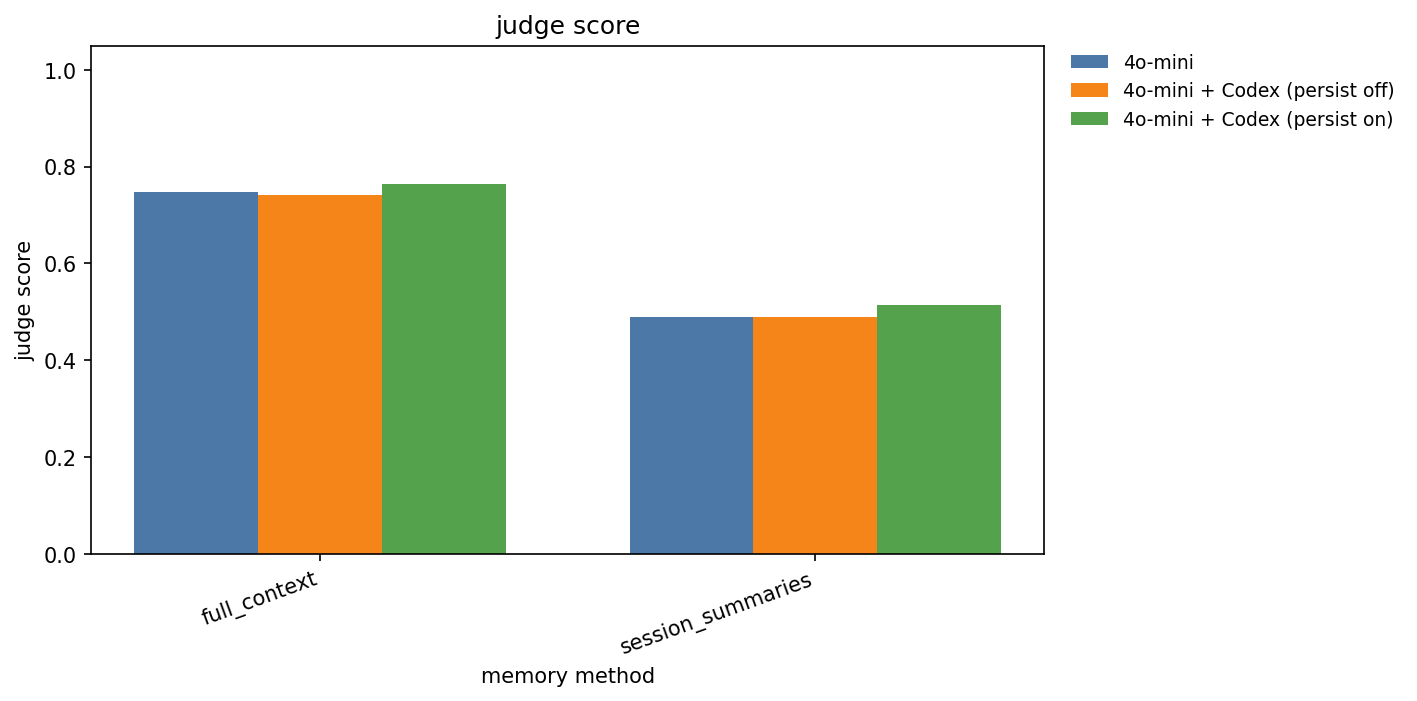

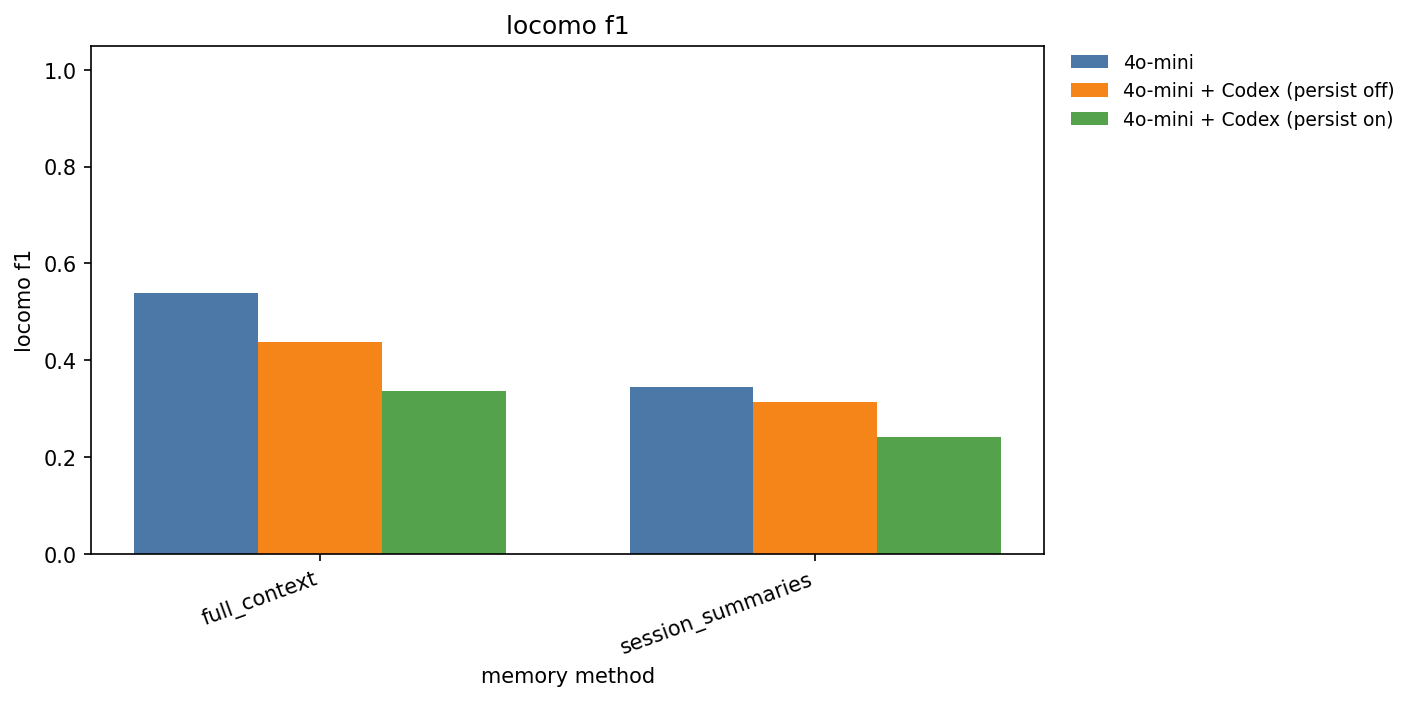

### Matched payload by LoCoMo category

question_category,memory_method,prompt_parity_condition,n,locomo_f1,judge_score
1 multi-hop,full_context,4o-mini,282,0.3785,0.6596
1 multi-hop,full_context,4o-mini + Codex (persist off),282,0.3127,0.6596
1 multi-hop,full_context,4o-mini + Codex (persist on),282,0.2663,0.7234
2 temporal,full_context,4o-mini,321,0.516,0.5576
2 temporal,full_context,4o-mini + Codex (persist off),321,0.3664,0.5452
2 temporal,full_context,4o-mini + Codex (persist on),321,0.2847,0.5265
3 open-domain,full_context,4o-mini,96,0.2453,0.4792
3 open-domain,full_context,4o-mini + Codex (persist off),96,0.2216,0.5312
3 open-domain,full_context,4o-mini + Codex (persist on),96,0.1505,0.5625
4 single-hop,full_context,4o-mini,841,0.6339,0.8799


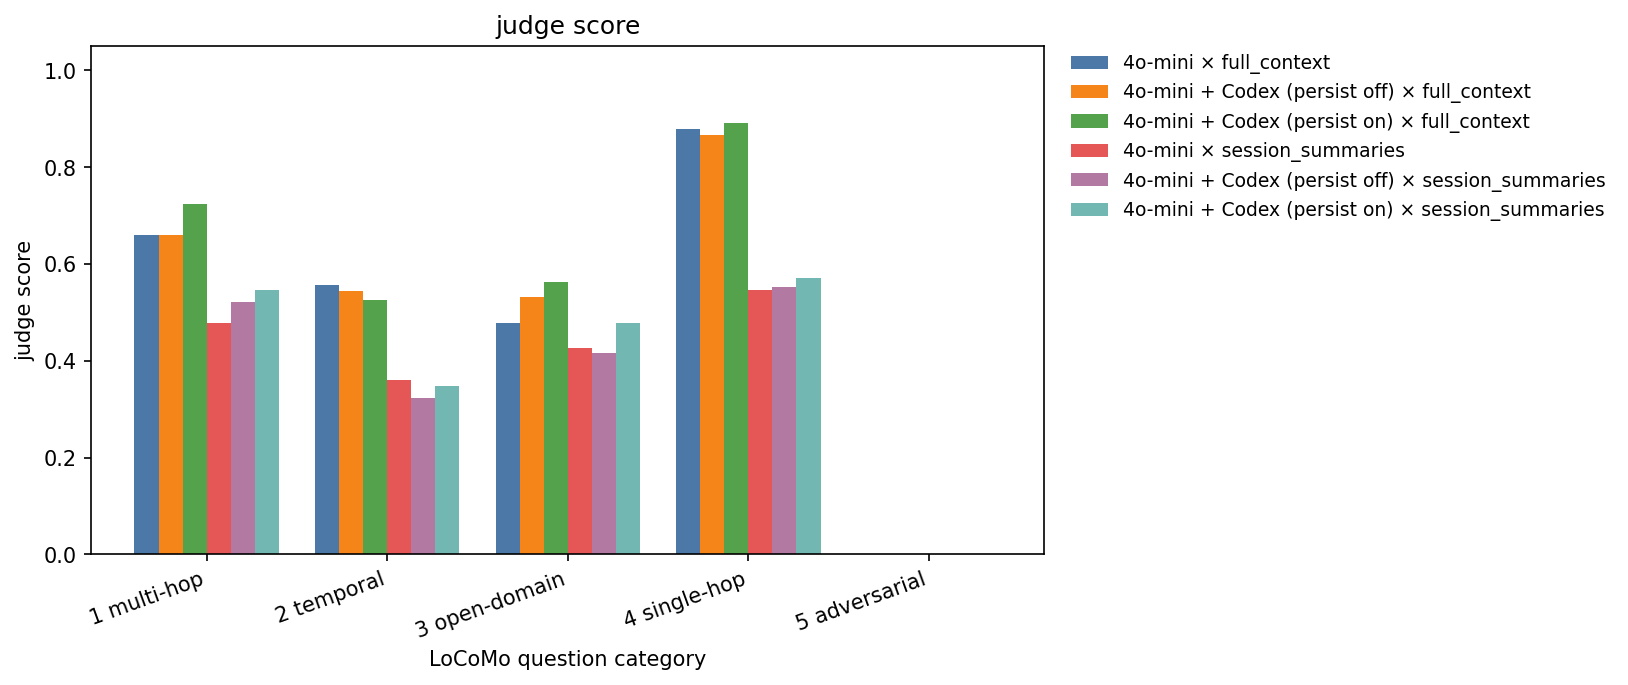

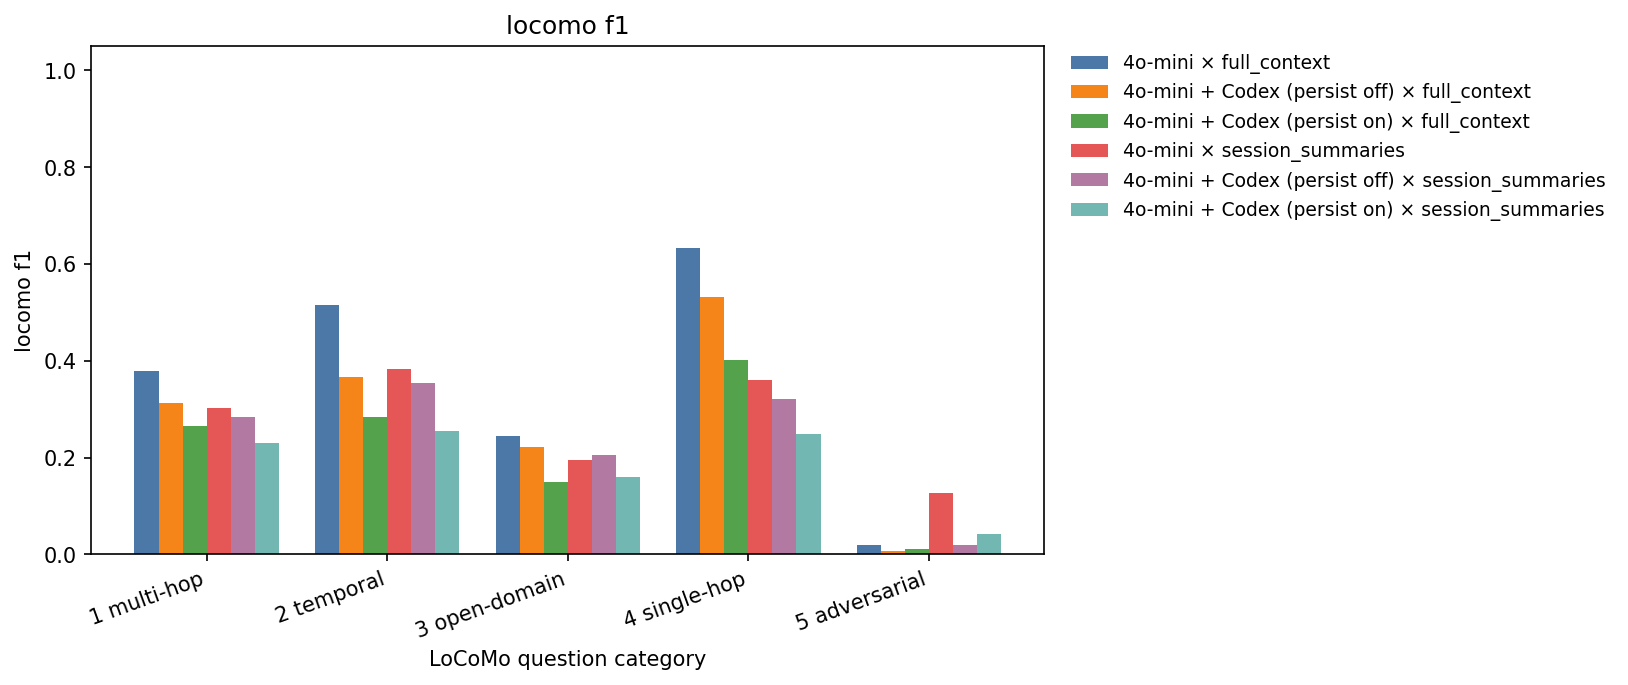

### Reader latency and list-price cost

memory_method,prompt_parity_condition,n,total_latency_seconds_p50,total_latency_seconds_p95,agent_latency_seconds_p50,agent_input_tokens,agent_output_tokens,reader_usd
full_context,4o-mini,1540,0.6505,1.5561,0.6505,27840.6883,6.1325,0.0042
full_context,4o-mini + Codex (persist off),1540,2.06,7.9825,2.06,34996.6883,10.9448,0.0053
full_context,4o-mini + Codex (persist on),1540,2.2518,8.5688,2.2518,36132.2825,23.4071,0.0054
session_summaries,4o-mini,1540,0.527,0.803,0.527,4071.9539,5.7987,0.0006
session_summaries,4o-mini + Codex (persist off),1540,1.6874,2.4516,1.6874,11343.4468,9.8305,0.0017
session_summaries,4o-mini + Codex (persist on),1540,1.7805,2.8257,1.7805,12047.4766,17.5896,0.0018


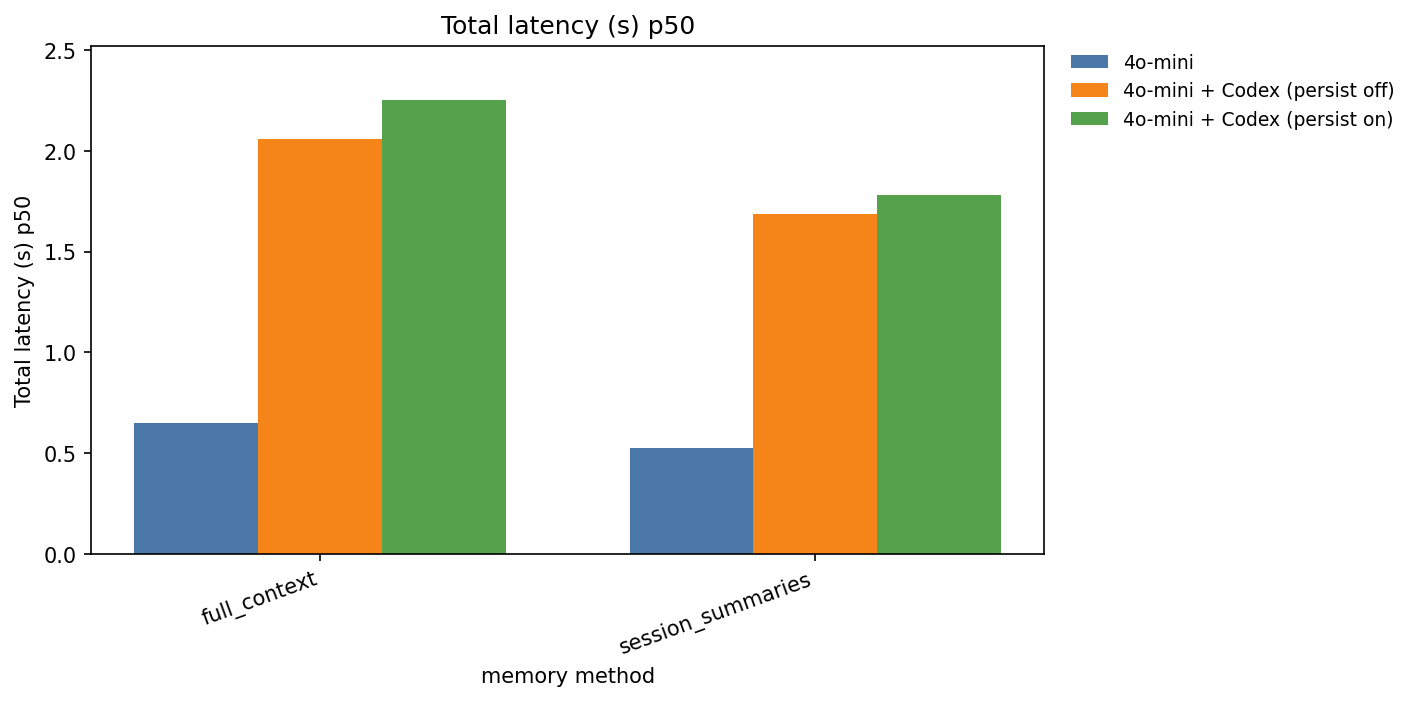

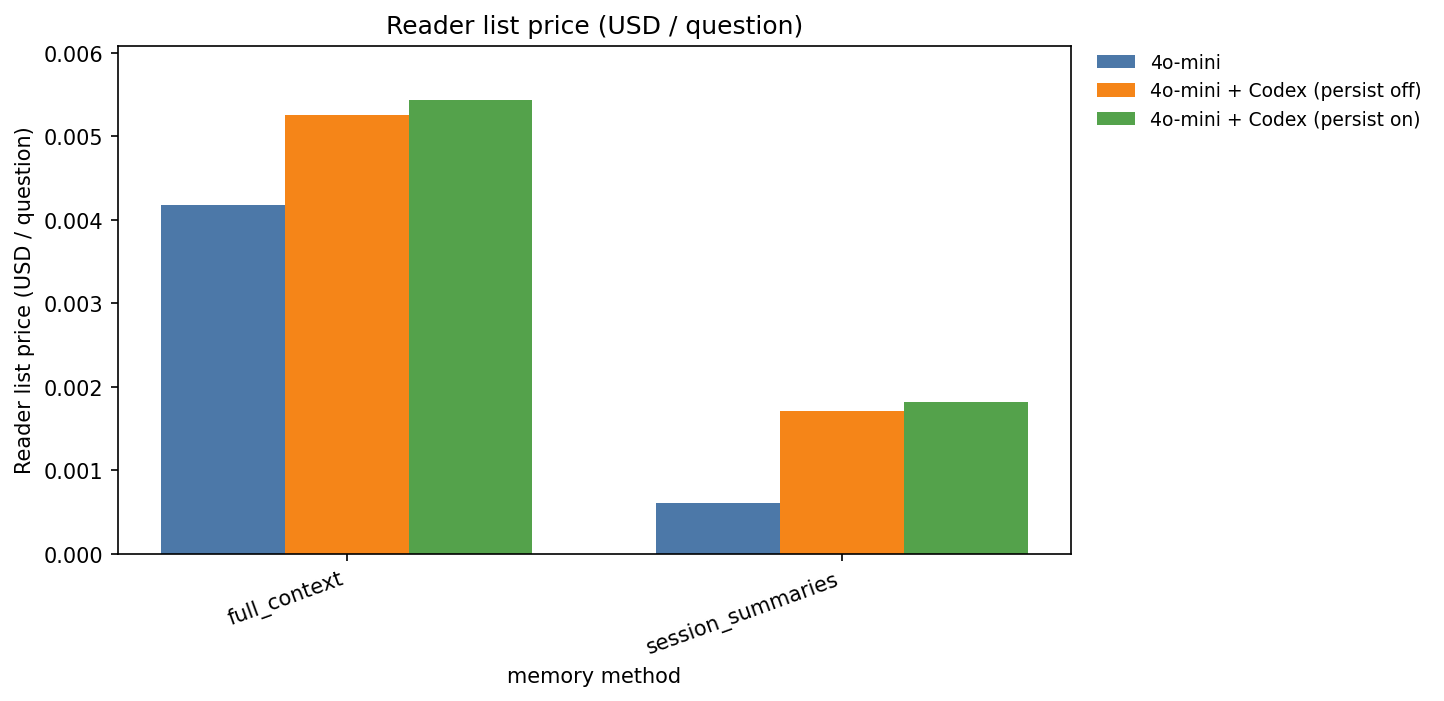

### Gold-token coverage and answer retention

memory_method,prompt_parity_condition,n,gold_memory_recall,gold_answer_recall,gold_answer_precision,gold_kept_given_memory,gold_dropped_given_memory
full_context,4o-mini,1540,0.9283,0.5947,0.5773,0.613,0.387
full_context,4o-mini + Codex (persist off),1540,0.9283,0.5886,0.427,0.6113,0.3887
full_context,4o-mini + Codex (persist on),1540,0.9283,0.6294,0.2799,0.6549,0.3451
session_summaries,4o-mini,1540,0.7335,0.3753,0.3832,0.44,0.56
session_summaries,4o-mini + Codex (persist off),1540,0.7335,0.384,0.335,0.4556,0.5444
session_summaries,4o-mini + Codex (persist on),1540,0.7335,0.3988,0.2127,0.4735,0.5265


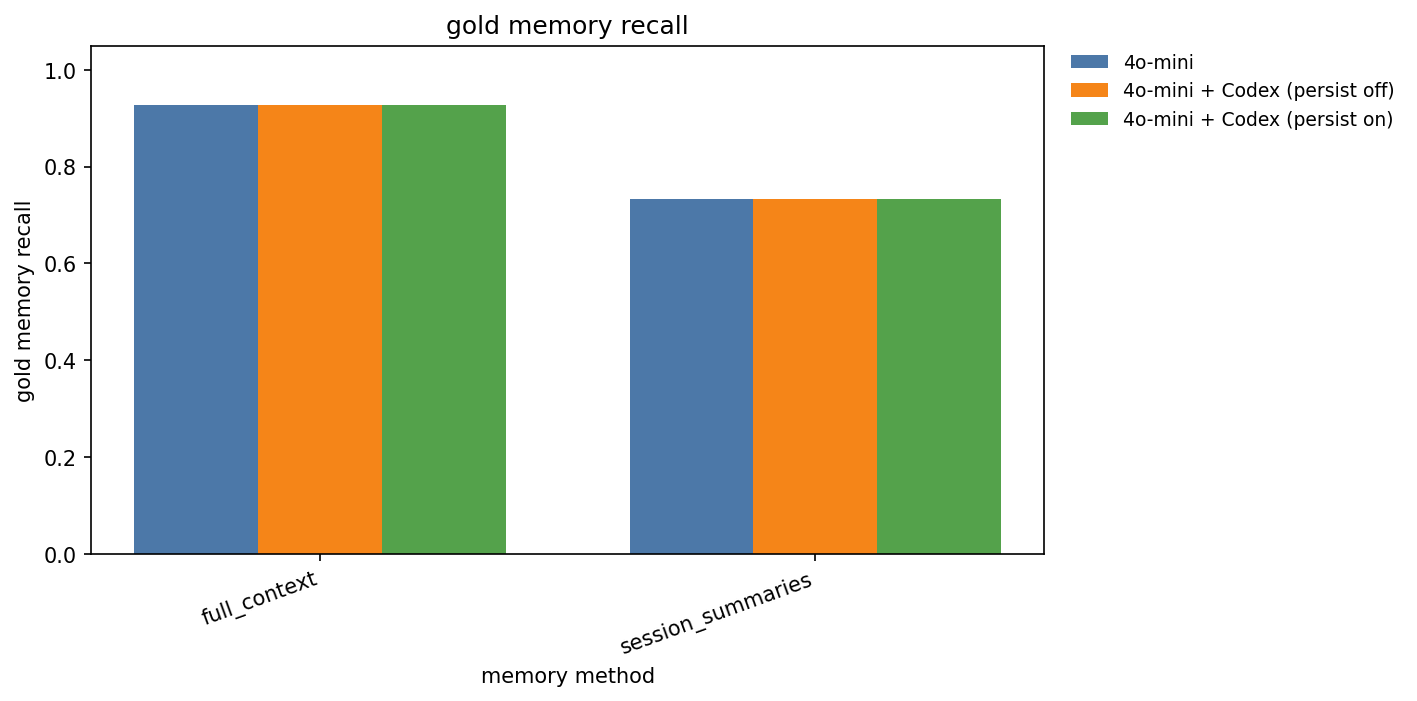

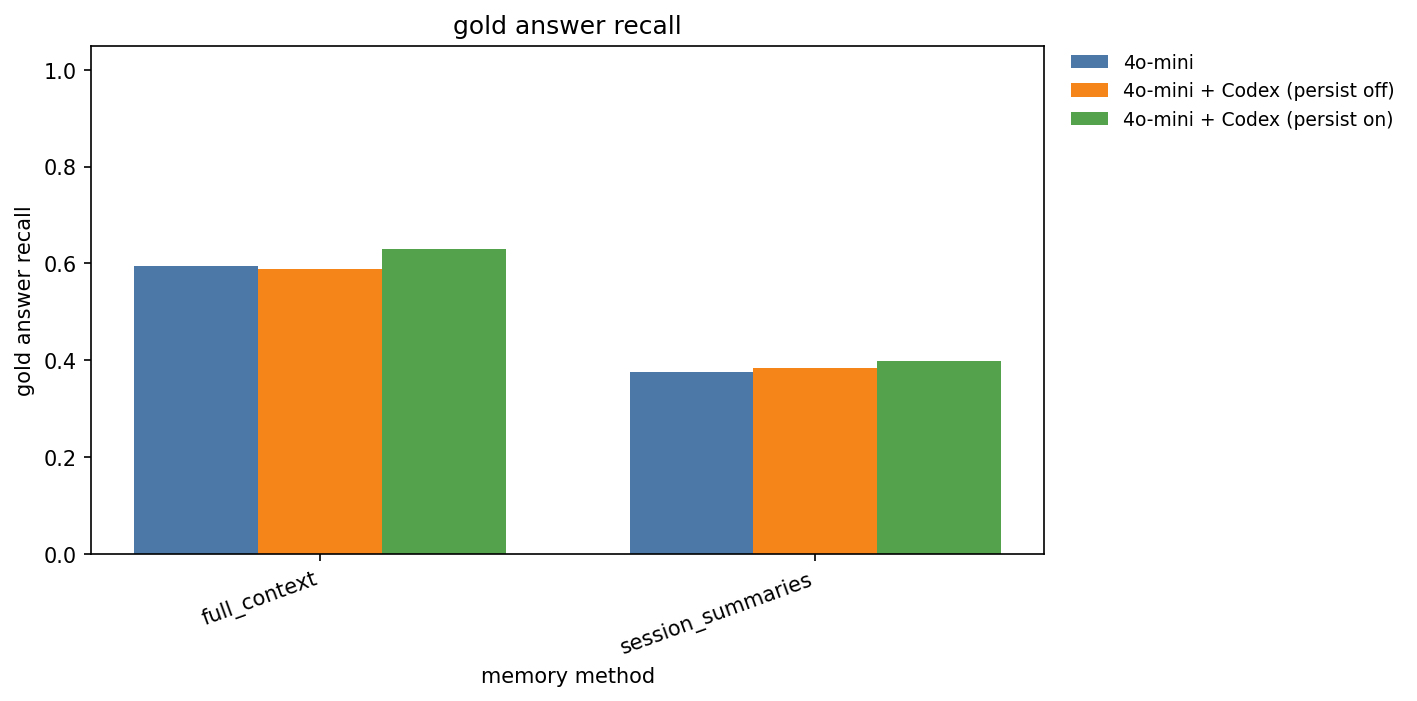

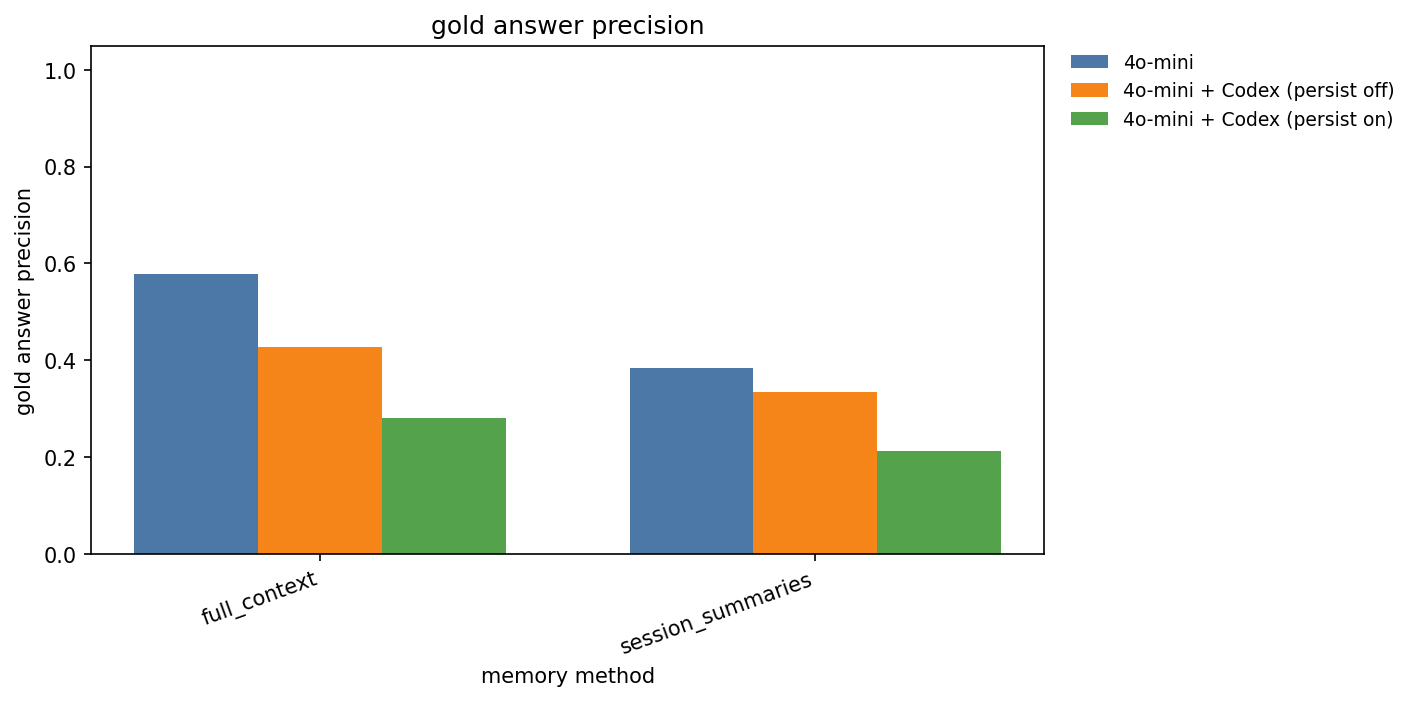

### Gold-token prompt coverage by category

question_category,memory_method,n,gold_memory_recall
1 multi-hop,full_context,282,0.9213
2 temporal,full_context,321,0.8645
3 open-domain,full_context,96,0.6281
4 single-hop,full_context,841,0.9893
1 multi-hop,session_summaries,282,0.7004
2 temporal,session_summaries,321,0.7822
3 open-domain,session_summaries,96,0.3793
4 single-hop,session_summaries,841,0.7664


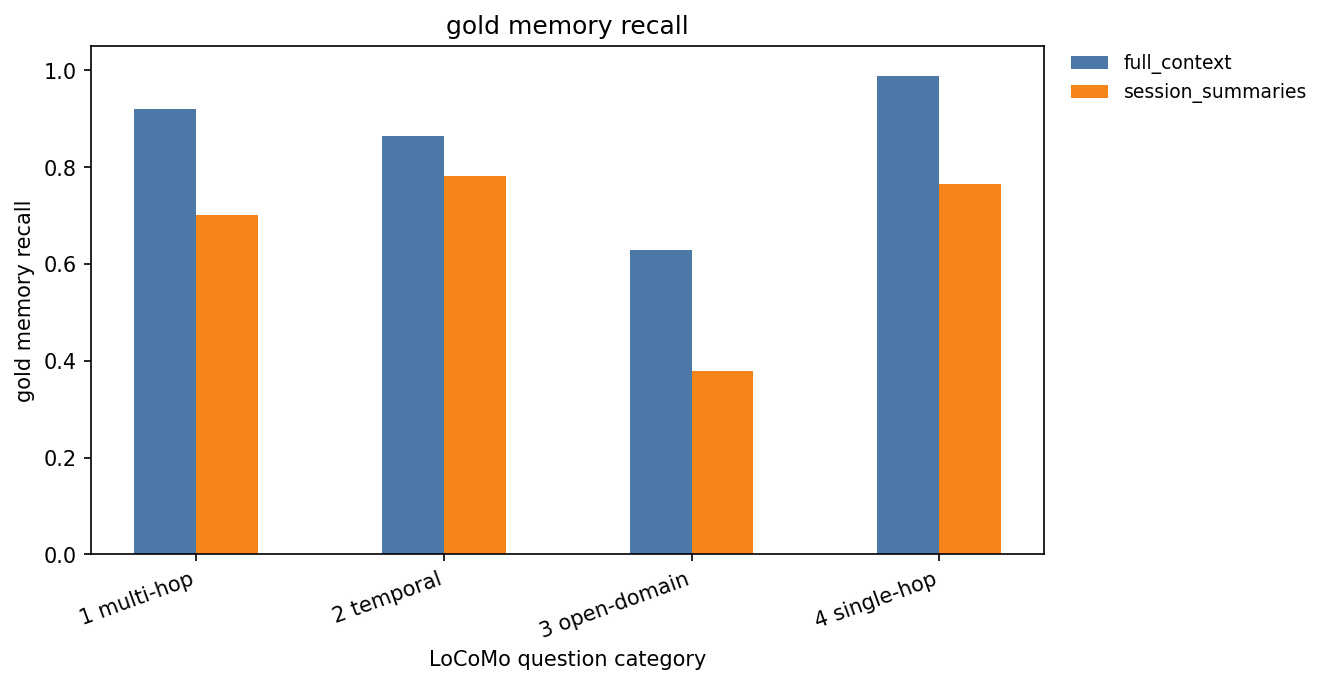

### Adversarial refusal and false refusal

memory_method,prompt_parity_condition,n,adversarial_refusal,adversarial_refusal_n,false_refusal,false_refusal_n
full_context,4o-mini,1986,0.0202,446,0.0026,1540
full_context,4o-mini + Codex (persist off),1986,0.0067,446,0.0013,1540
full_context,4o-mini + Codex (persist on),1986,0.0112,446,0.0006,1540
session_summaries,4o-mini,1986,0.1278,446,0.0468,1540
session_summaries,4o-mini + Codex (persist off),1986,0.0202,446,0.0097,1540
session_summaries,4o-mini + Codex (persist on),1986,0.0426,446,0.0078,1540


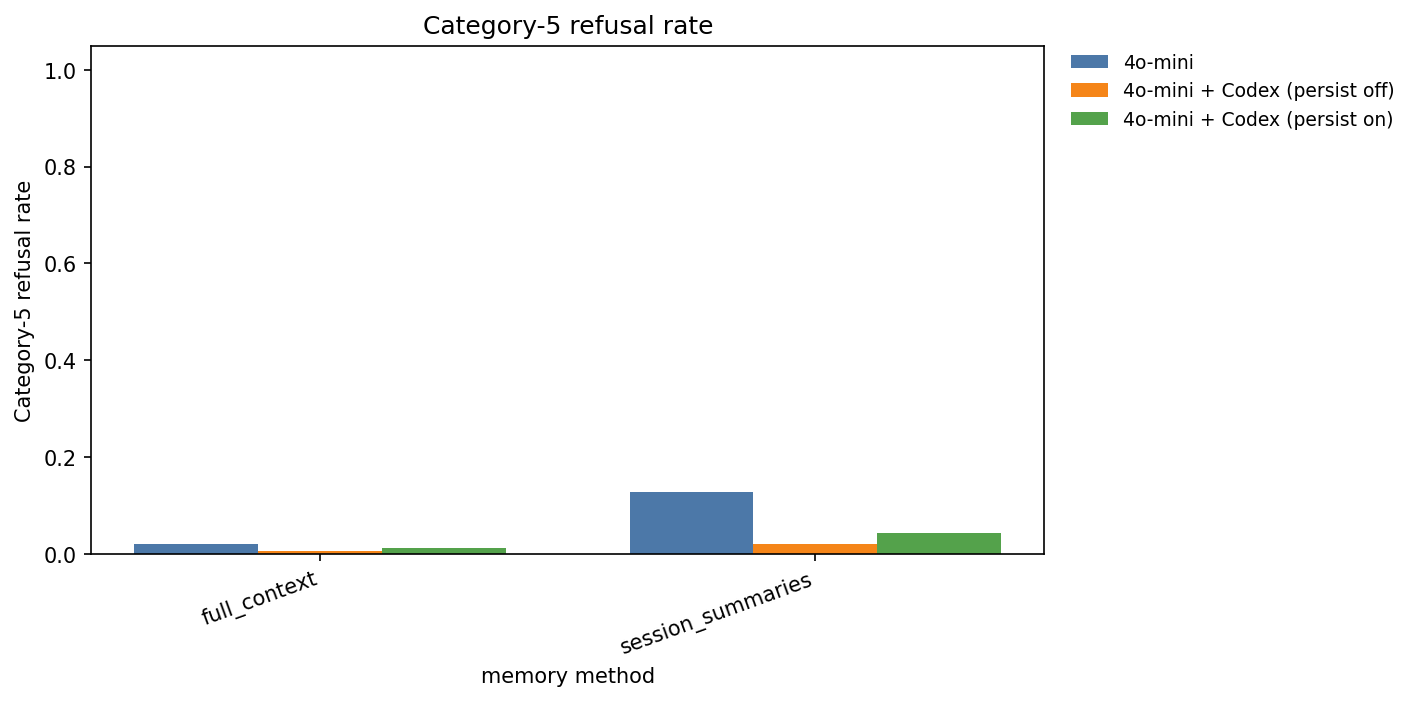

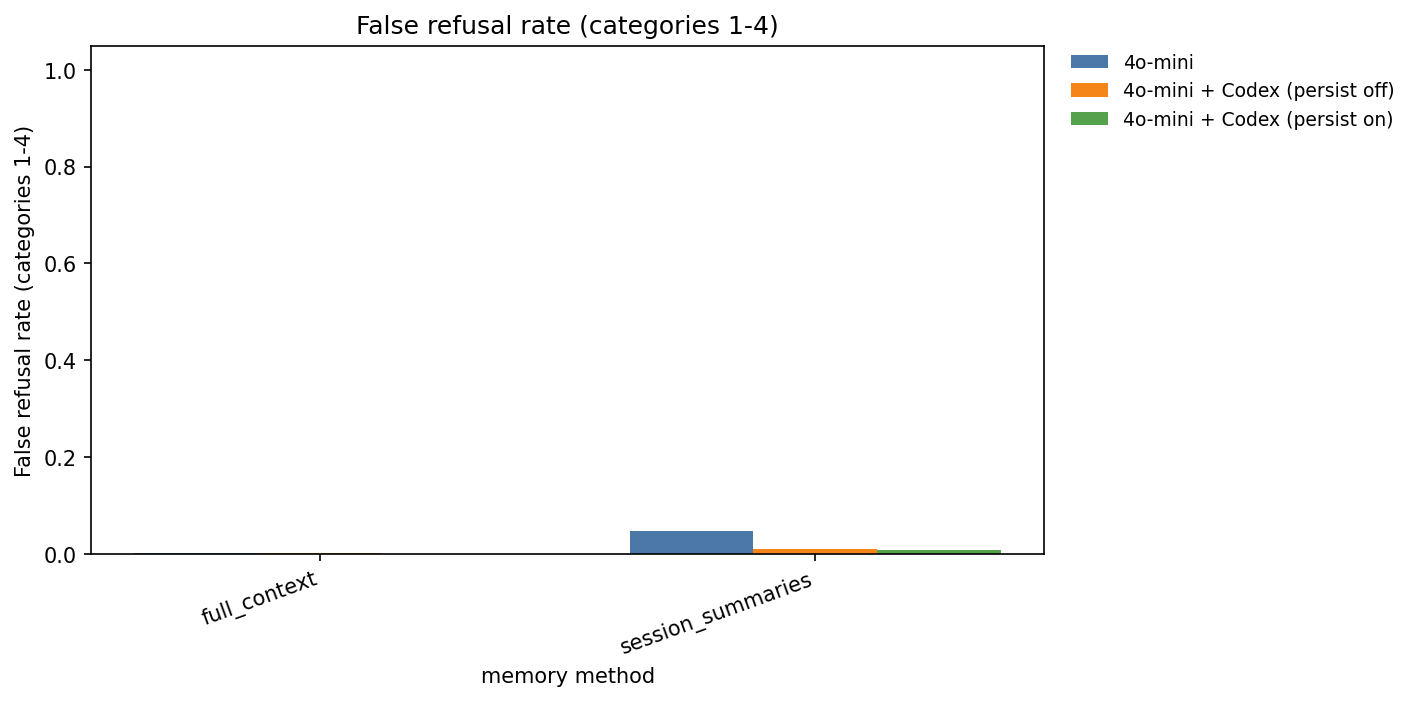

### Codex tool and persistence audit

memory_method,agent_persist,n,n_web_search,n_mcp,used_non_workspace_tools,n_write_events,notes_retrieved,notes_bytes,harness_failed_rate
full_context,false,1,0,0,0,0,0,,0
full_context,true,1,0,0,0,0.0191,0.002,268.3087,0
session_summaries,false,1,0,0,0,0,0,,0
session_summaries,true,1,0,0,0,0.0131,0.0161,204.929,0


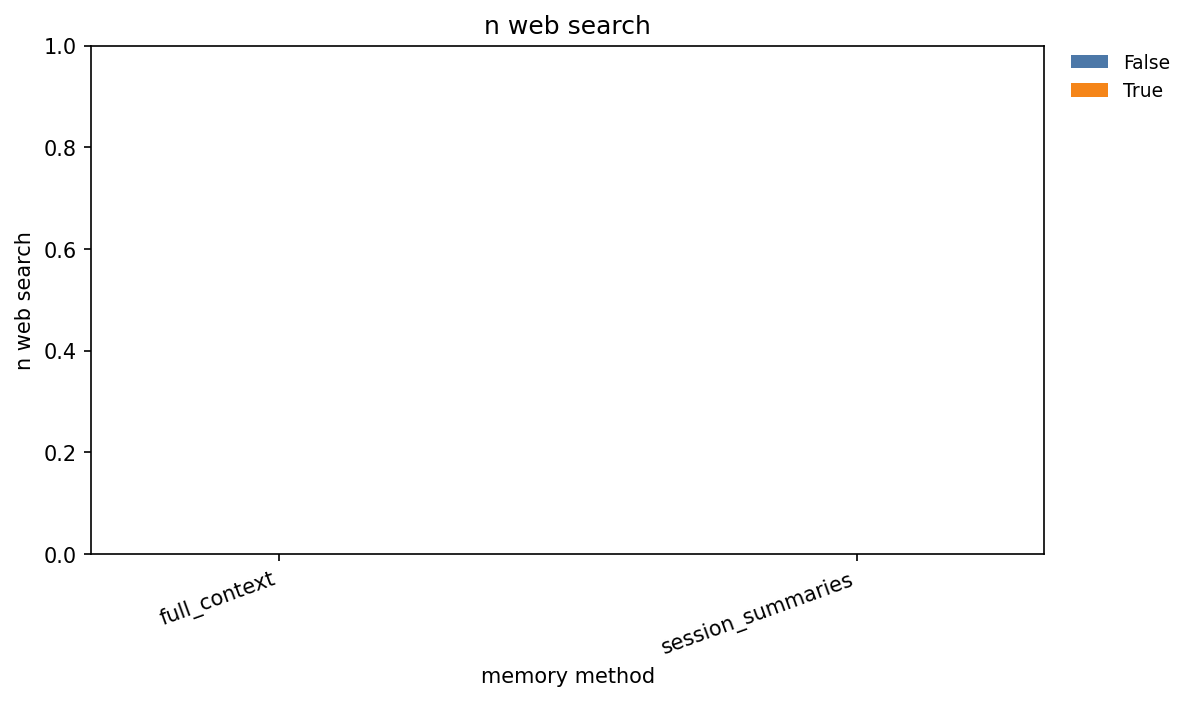

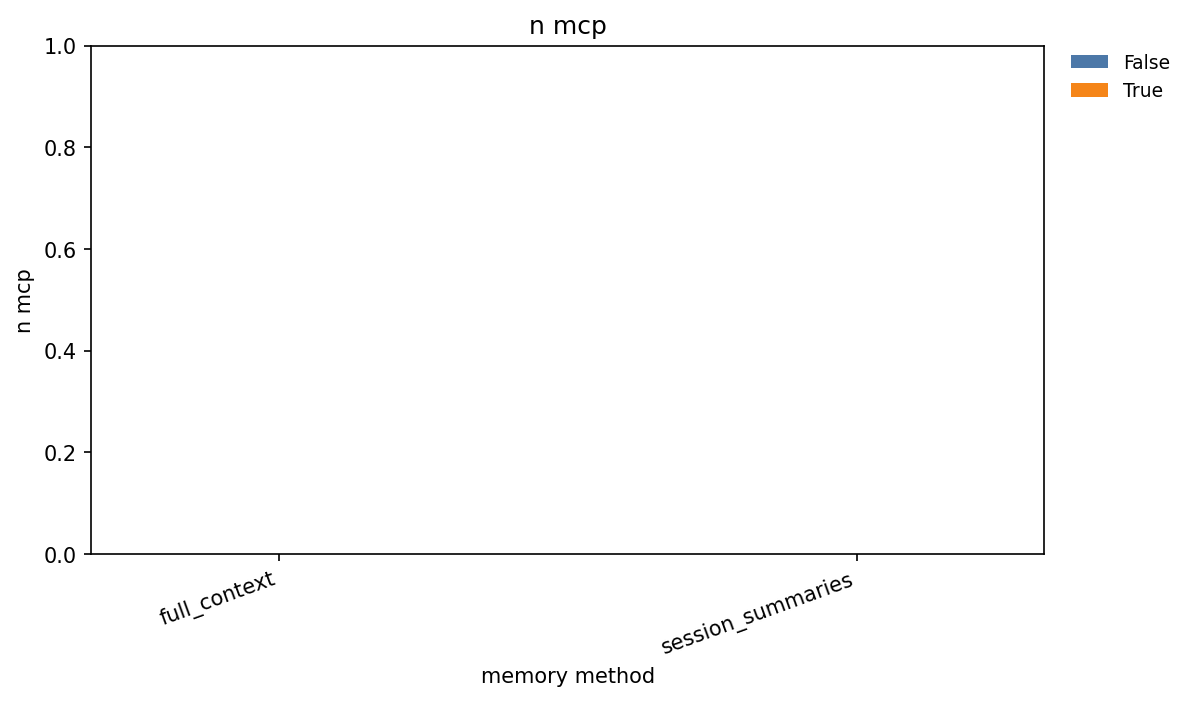

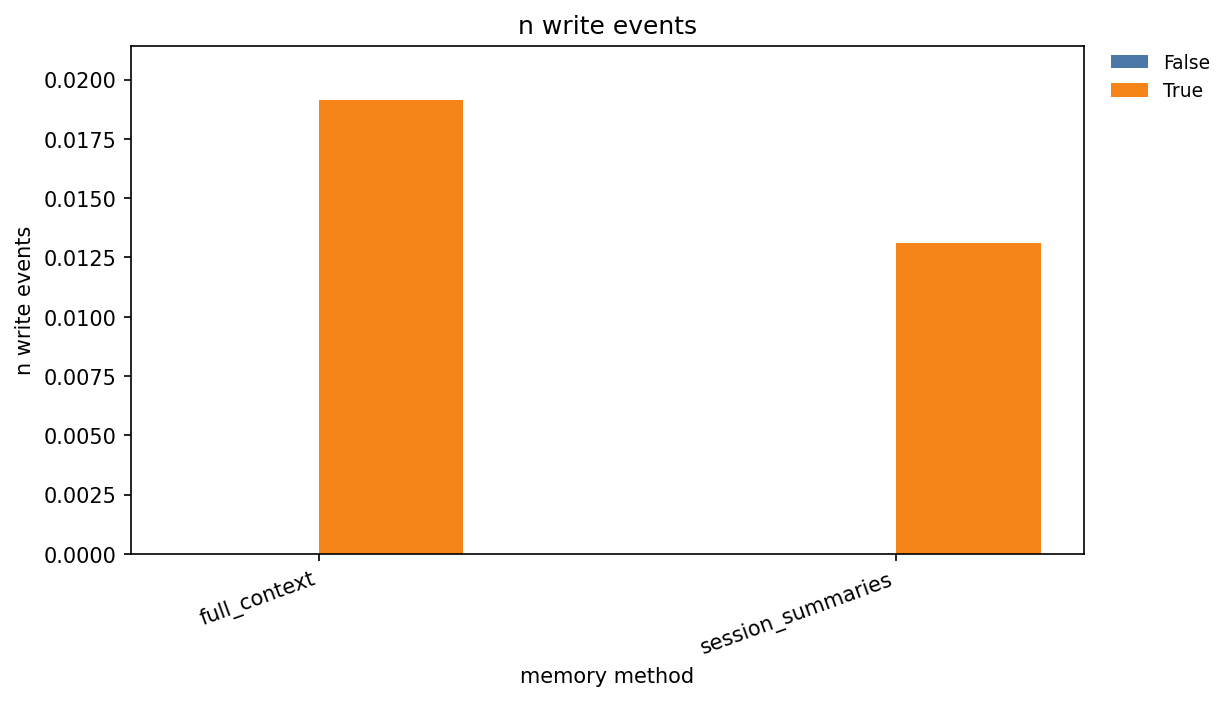

### Post-test

check,result,detail
readers.scientific_claim,SKIP,declared not a scientific claim (smoke / subset)
readers.n_cells,PASS,"expected 6, actual 6"


Post-test: declared expectations matched the pack where data exists.

,check,result,detail
0,readers.scientific_claim,SKIP,declared not a scientific claim (smoke / subset)
1,readers.n_cells,PASS,"expected 6, actual 6"


In [2]:
import sys
from pathlib import Path

# Jupyter puts the notebook directory on sys.path. The package lives at the repo root.
ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir() and (ROOT.parent / "src").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiment_runner.analysis import (
    load_campaign_yaml,
    notebook_posttest,
    notebook_pretest,
    notebook_show,
    run_report,
)

YAML = ROOT / "configs/analysis/campaign_openai_mini_codex_readers_analysis.yaml"
camp = load_campaign_yaml(YAML)
notebook_pretest(camp, root=ROOT)
reports = run_report(YAML, root=ROOT)
report = reports[-1]
notebook_posttest(camp, report=reports, root=ROOT)


## Quality

Judge score and LoCoMo F1 score the same predicted string. The judge accepts a paraphrase. F1 falls when the answer adds words that are not in the reference.

On answerable questions (n = 1540), full-context judge score is 0.747 for the model, 0.741 for persist-off, and 0.764 for persist-on. LoCoMo F1 is 0.538, 0.438, and 0.337. Session summaries are 0.488, 0.490, and 0.515 on the judge, and 0.344, 0.314, and 0.241 on F1. Mean answer length moves from 4.1 to 6.4 to 14.1 words on full context, and from 4.0 to 5.1 to 9.3 words on summaries.

Persist-on is a small judge gain and a large F1 loss. The category figure is mixed: persist-on does not raise judge score in every category. The category-5 judge bar is the skip placeholder 0. The category-5 F1 bar is the refusal phrase, read again in Abstention.


### Matched reader payload conditions

memory_method,prompt_parity_condition,n,judge_score,locomo_f1,token_f1,exact_match,answer_n_words
full_context,4o-mini,1540,0.7474,0.5383,0.5319,0.211,4.0994
full_context,4o-mini + Codex (persist off),1540,0.7409,0.4382,0.4336,0.1188,6.3721
full_context,4o-mini + Codex (persist on),1540,0.7636,0.3367,0.3304,0.0338,14.1221
session_summaries,4o-mini,1540,0.4883,0.3441,0.3359,0.1143,4.013
session_summaries,4o-mini + Codex (persist off),1540,0.4903,0.314,0.308,0.0883,5.1442
session_summaries,4o-mini + Codex (persist on),1540,0.5149,0.2407,0.2344,0.0234,9.2844


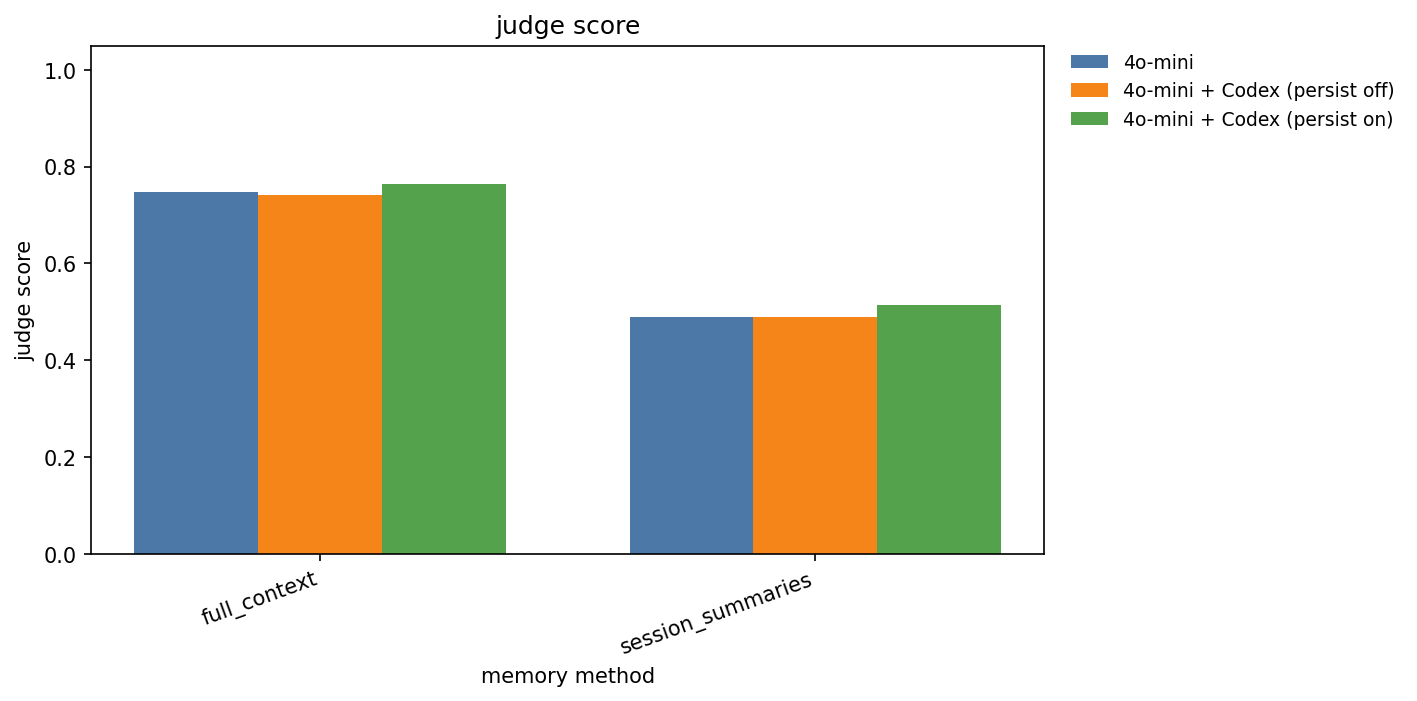

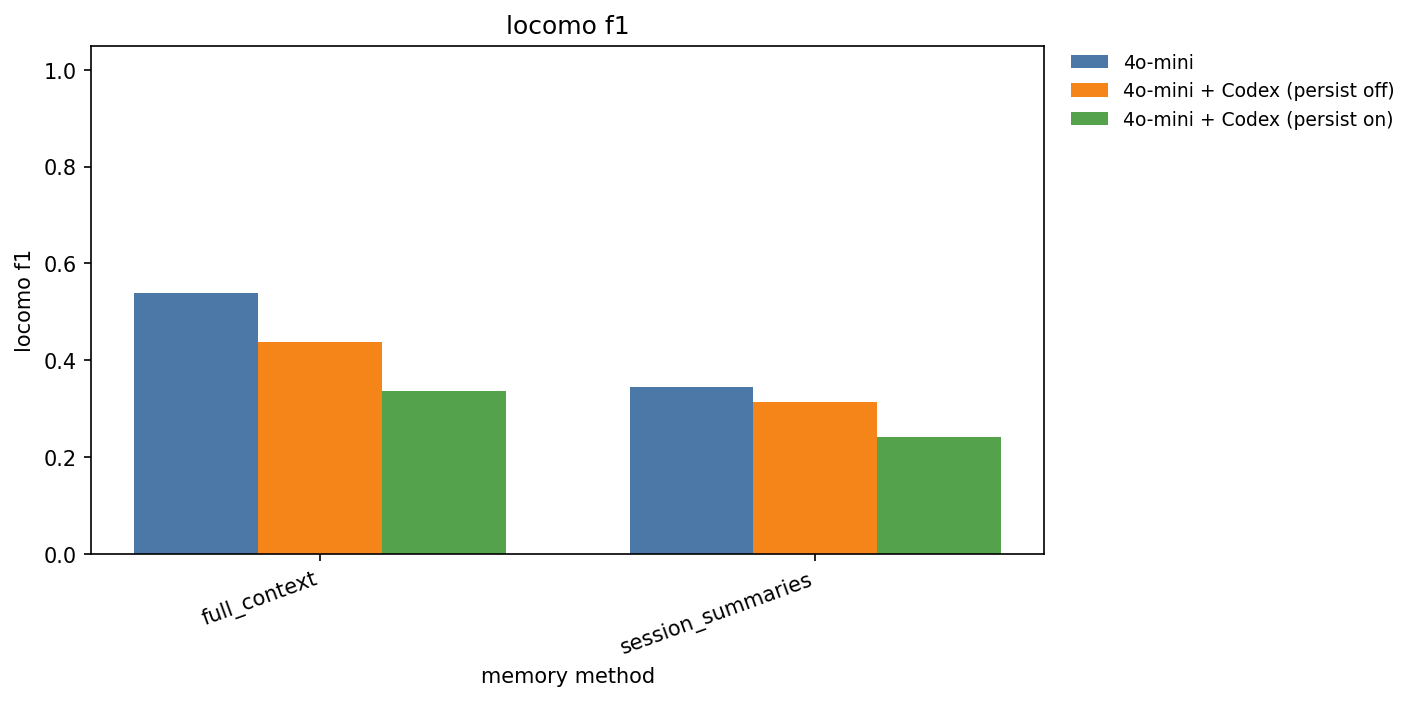

### Matched payload by LoCoMo category

question_category,memory_method,prompt_parity_condition,n,locomo_f1,judge_score
1 multi-hop,full_context,4o-mini,282,0.3785,0.6596
1 multi-hop,full_context,4o-mini + Codex (persist off),282,0.3127,0.6596
1 multi-hop,full_context,4o-mini + Codex (persist on),282,0.2663,0.7234
2 temporal,full_context,4o-mini,321,0.516,0.5576
2 temporal,full_context,4o-mini + Codex (persist off),321,0.3664,0.5452
2 temporal,full_context,4o-mini + Codex (persist on),321,0.2847,0.5265
3 open-domain,full_context,4o-mini,96,0.2453,0.4792
3 open-domain,full_context,4o-mini + Codex (persist off),96,0.2216,0.5312
3 open-domain,full_context,4o-mini + Codex (persist on),96,0.1505,0.5625
4 single-hop,full_context,4o-mini,841,0.6339,0.8799


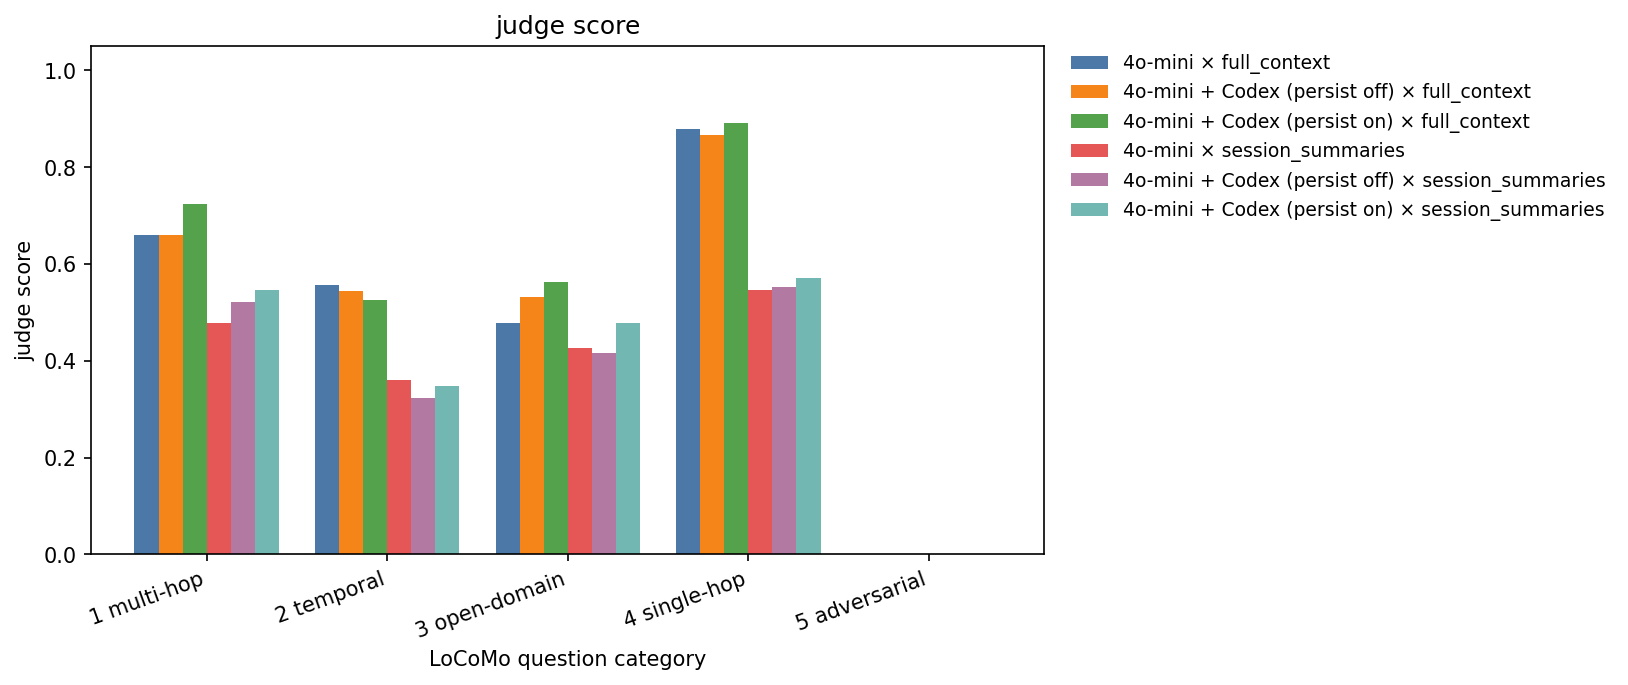

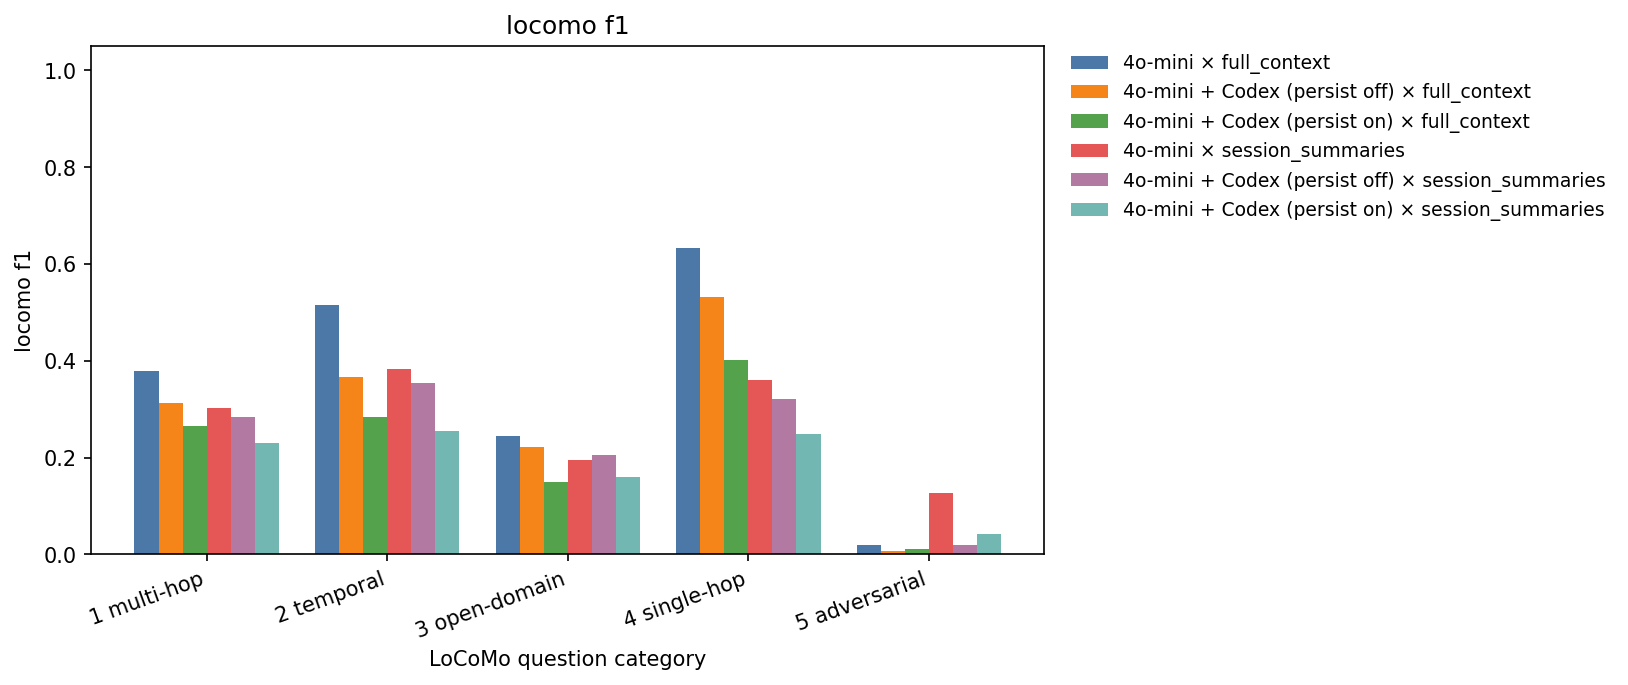

In [3]:
notebook_show(report, only=("reader_conditions", "reader_by_category"), header=False)


## Performance

Search latency is 0 in every cell because the memory text is already in the prompt. Total latency is the wall clock of the reader call, including Codex process startup. List price uses `configs/models/pricing.yaml` (GPT-4o-mini, $0.15 / 1M input tokens and $0.60 / 1M output tokens, pin date 2026-09-16) at the cache-miss rate. Category 5 is excluded so the rows match the quality table. The judge is not in `reader_usd`.

Full-context p50 latency is 0.65 s for the model, 2.06 s for persist-off, and 2.25 s for persist-on. Mean list price per answerable question is $0.00418, $0.00526, and $0.00543. Summaries are cheaper and faster: p50 0.53 s, 1.69 s, and 1.78 s, at $0.00061, $0.00171, and $0.00182.

This run is not a multi-call agent loop. All 1,986 questions have one `turn.completed`. Persist-off ran one shell command in the whole cell. Persist-on full context ran a command on 41 questions. Those 41 already sit inside the mean: about 72,000 input tokens and 146 output tokens, against about 35,000 and 21 on questions with no command. The dollar gap versus the model is one longer request (about 28k input tokens versus about 35k of harness wrapping) plus startup time. Latency rises about 3.2 times. The list-price bill rises about 1.3 times. Cached input is billed here at the full rate, so a real invoice can be lower.


### Reader latency and list-price cost

memory_method,prompt_parity_condition,n,total_latency_seconds_p50,total_latency_seconds_p95,agent_latency_seconds_p50,agent_input_tokens,agent_output_tokens,reader_usd
full_context,4o-mini,1540,0.6505,1.5561,0.6505,27840.6883,6.1325,0.0042
full_context,4o-mini + Codex (persist off),1540,2.06,7.9825,2.06,34996.6883,10.9448,0.0053
full_context,4o-mini + Codex (persist on),1540,2.2518,8.5688,2.2518,36132.2825,23.4071,0.0054
session_summaries,4o-mini,1540,0.527,0.803,0.527,4071.9539,5.7987,0.0006
session_summaries,4o-mini + Codex (persist off),1540,1.6874,2.4516,1.6874,11343.4468,9.8305,0.0017
session_summaries,4o-mini + Codex (persist on),1540,1.7805,2.8257,1.7805,12047.4766,17.5896,0.0018


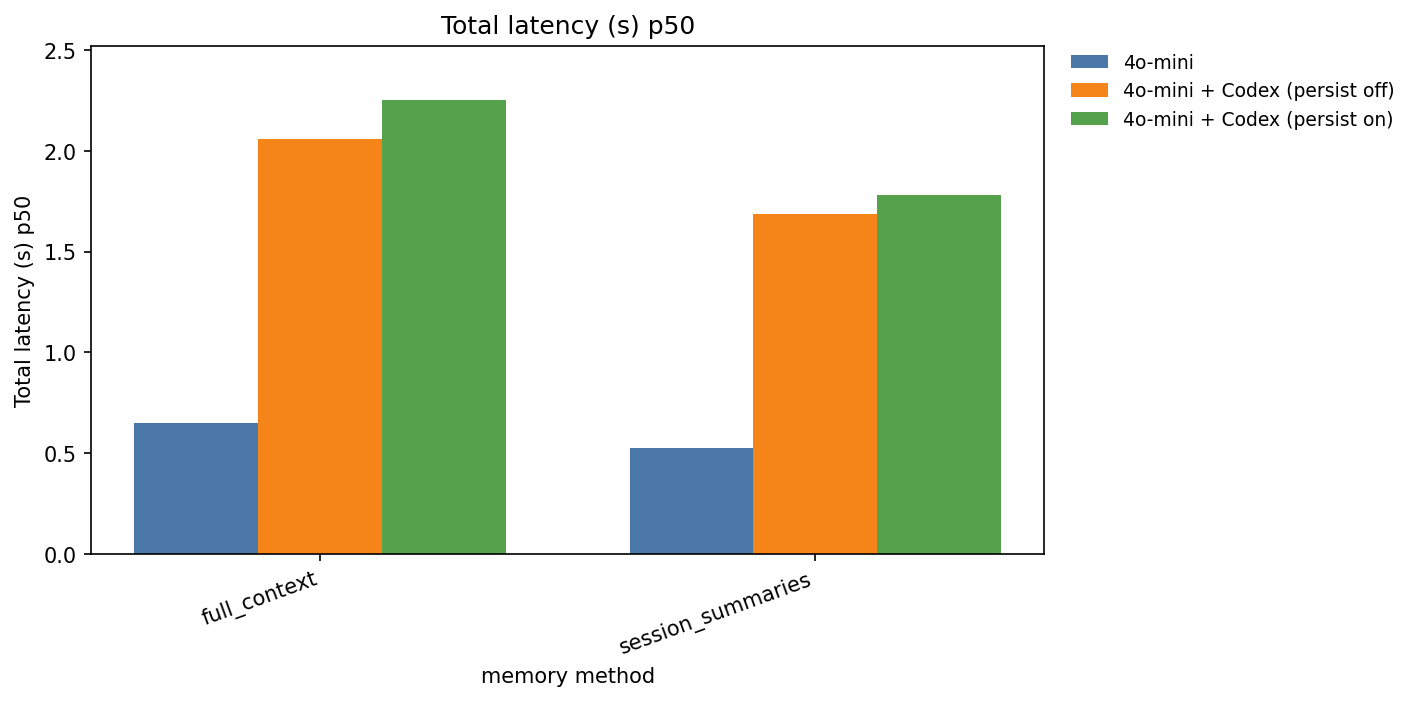

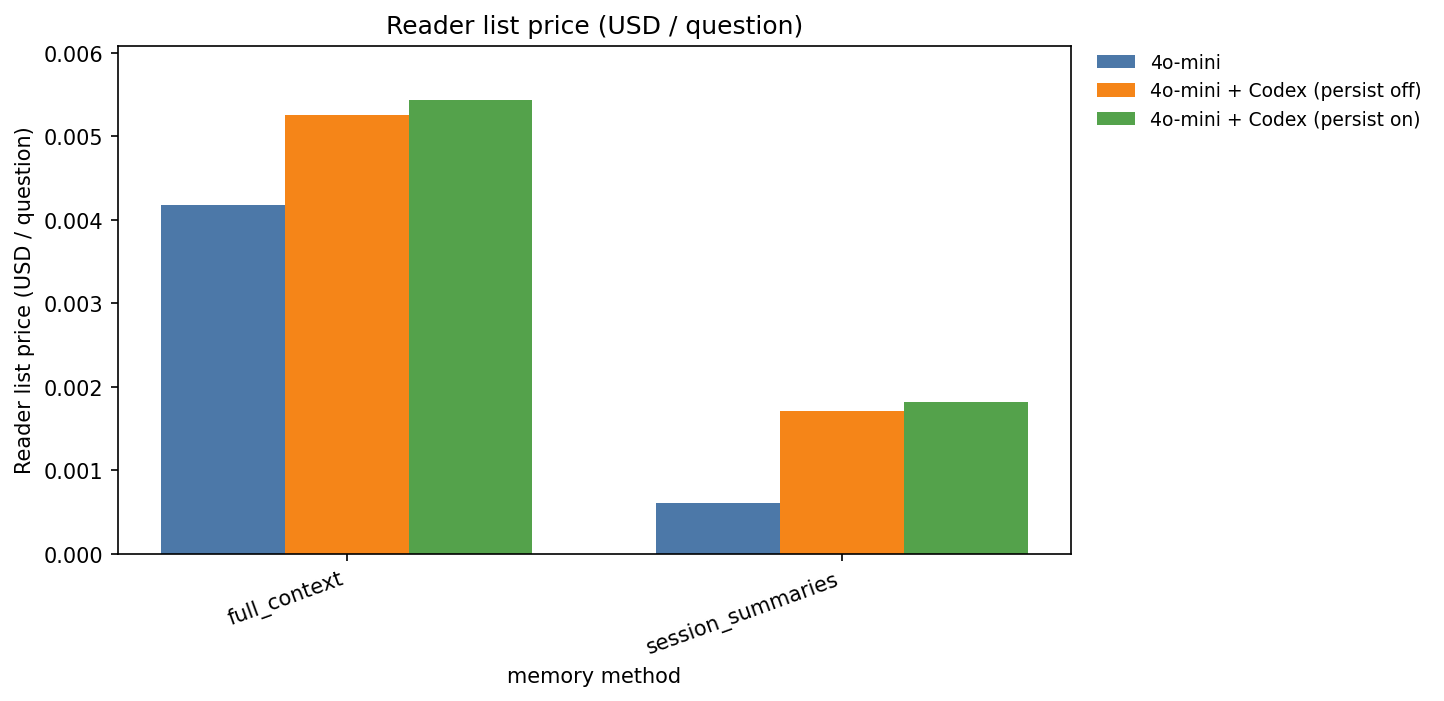

In [4]:
notebook_show(report, only=("reader_performance",), header=False)


## Retention

Gold stems are the reference answer's content words, not strings that the prompt had and the answer lost. Memory recall asks whether those words are in the memory text. Answer recall asks whether they are in the answer. Answer precision asks what share of the answer is those words. Kept given memory asks, among gold stems that were in the memory text, how many the answer still contains. Dropped given memory is the rest of that same set. It is in the table because it is 1 minus kept. It is not a separate stage and it has no plot.

Memory recall is 0.928 for full context and 0.733 for session summaries, and it is the same number for the model and both Codex cells. The summaries gap is the memory text. The harness does not build that text.

Answer recall on full context is 0.595, 0.589, and 0.629. Persist-off does not find more of the reference. Persist-on finds a small amount more. Kept given memory tells the same story: 0.613, 0.611, and 0.655. The agent does not keep the whole reference when it was in the prompt. It keeps about two-thirds of those stems, close to the model.

The precision gap is the answer getting longer. Token-weighted, full-context answers overlap the reference by 1.94, 2.02, and 2.30 stems, while the answers themselves are 3.61, 5.60, and 10.64 stems. Persist-off finds about the same gold stems and writes about two extra stems. Persist-on finds about 0.36 more gold stems and writes about seven extra stems. Precision falls because the denominator grows. Recall and precision already describe that. A further stemming or pruning metric would restate the same two ratios.

The shared prompt already says the answer should be less than 5-6 words. The model averages 4.1 words. Persist-off, with that same payload, averages 6.4. The notes footer is not required to explain the first precision drop. It does line up with the further jump to 14.1 words.


### Gold-token coverage and answer retention

memory_method,prompt_parity_condition,n,gold_memory_recall,gold_answer_recall,gold_answer_precision,gold_kept_given_memory,gold_dropped_given_memory
full_context,4o-mini,1540,0.9283,0.5947,0.5773,0.613,0.387
full_context,4o-mini + Codex (persist off),1540,0.9283,0.5886,0.427,0.6113,0.3887
full_context,4o-mini + Codex (persist on),1540,0.9283,0.6294,0.2799,0.6549,0.3451
session_summaries,4o-mini,1540,0.7335,0.3753,0.3832,0.44,0.56
session_summaries,4o-mini + Codex (persist off),1540,0.7335,0.384,0.335,0.4556,0.5444
session_summaries,4o-mini + Codex (persist on),1540,0.7335,0.3988,0.2127,0.4735,0.5265


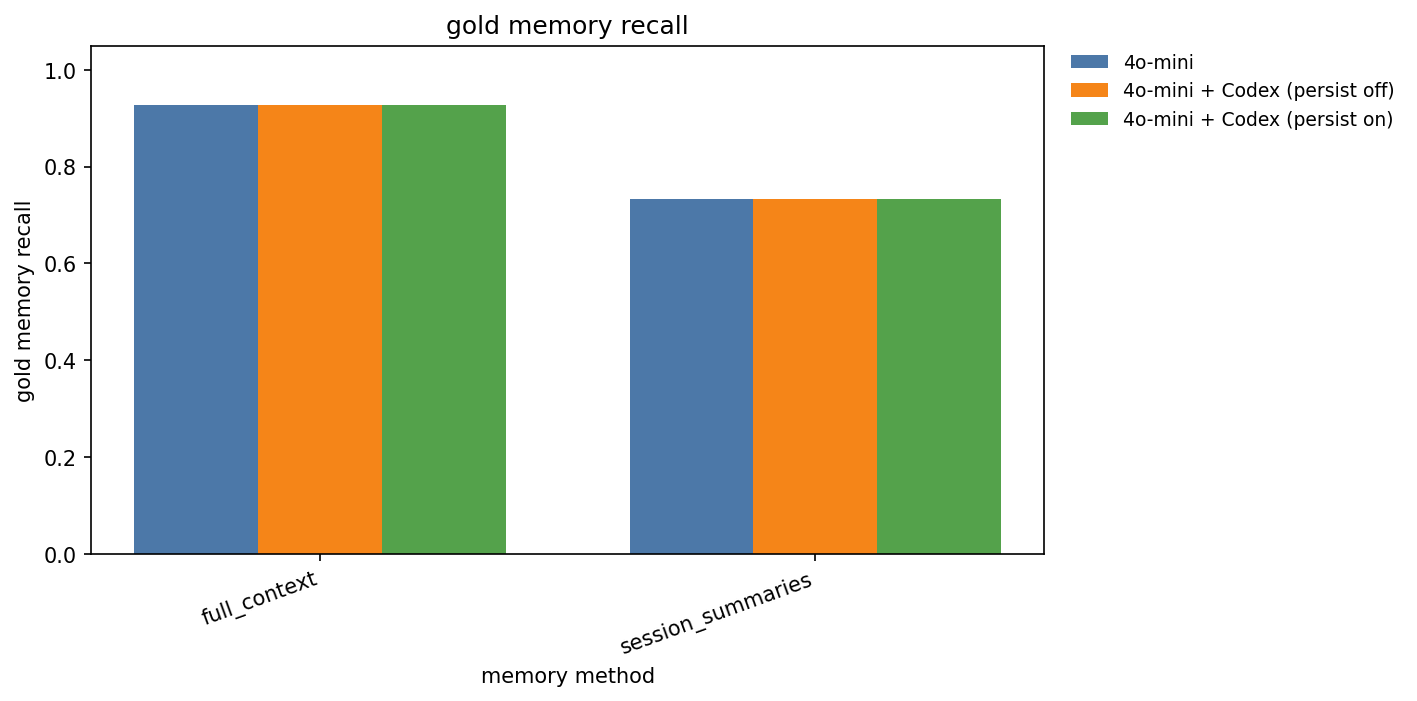

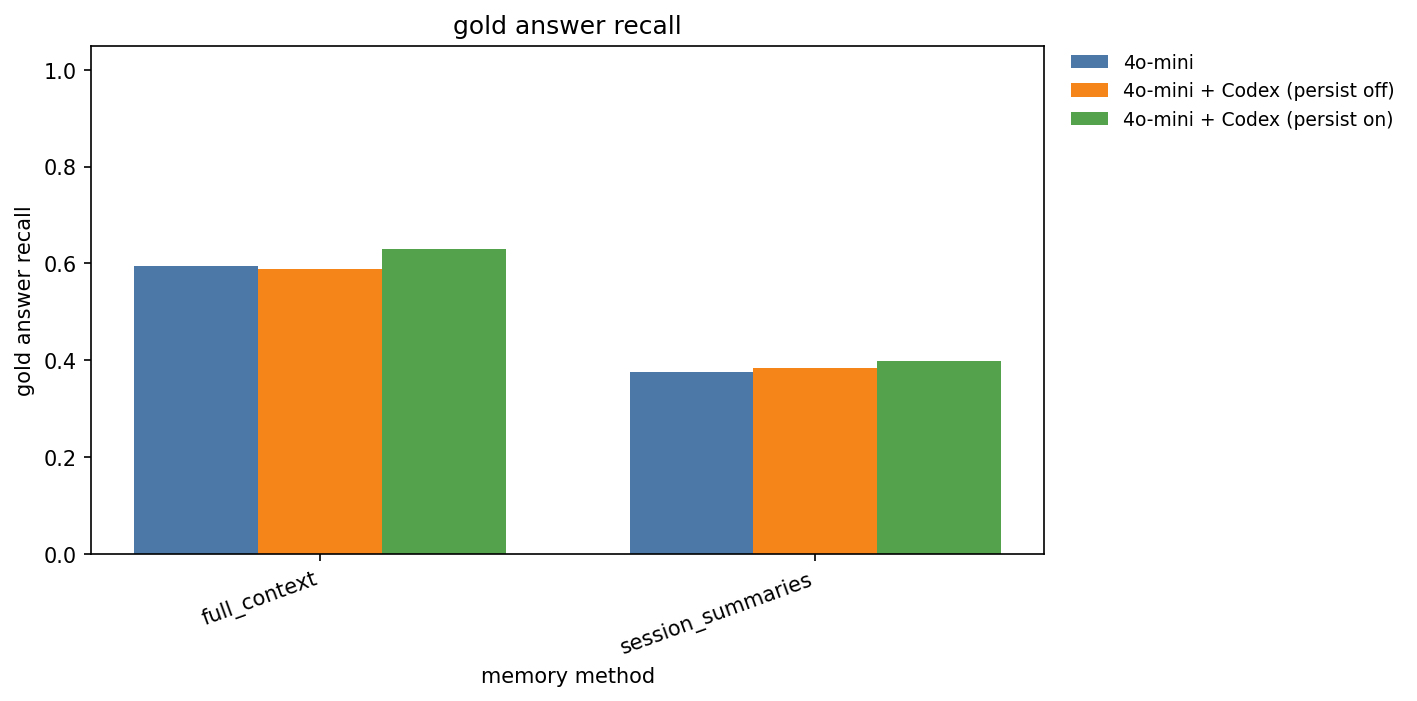

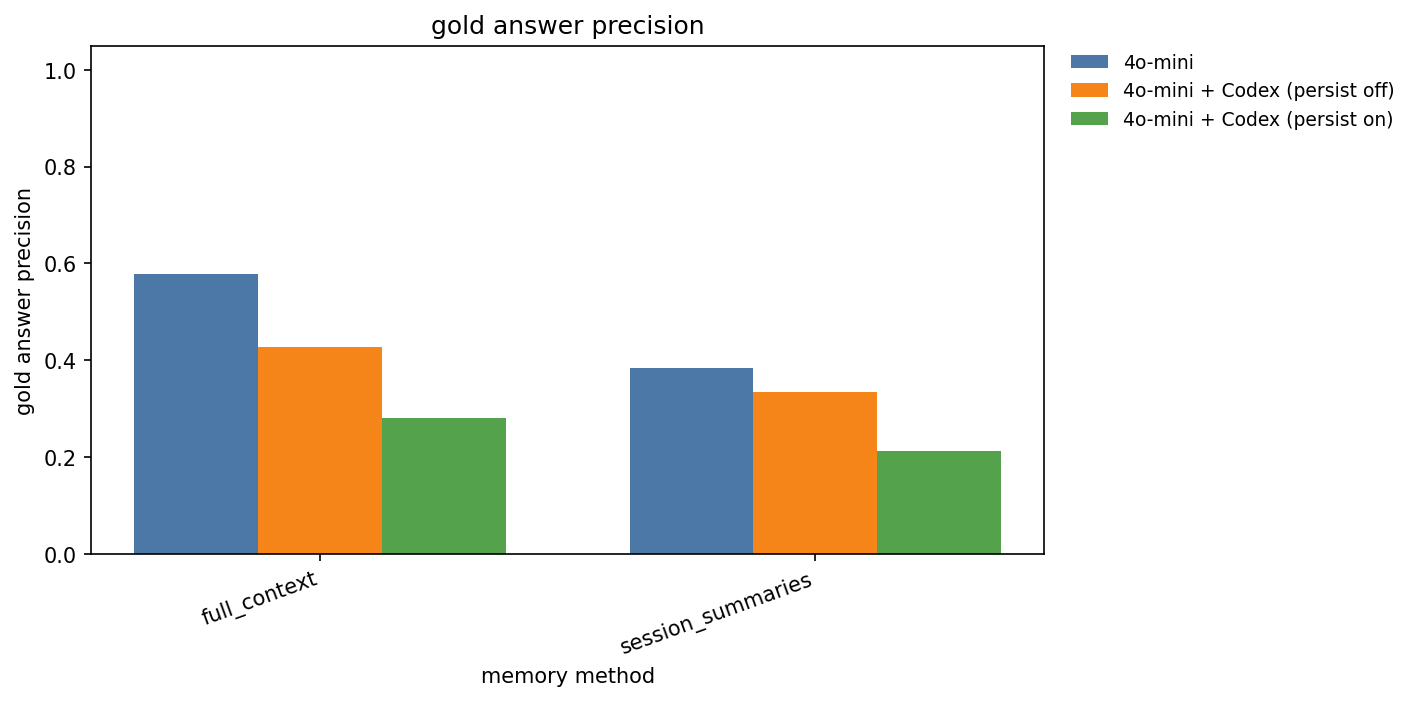

### Gold-token prompt coverage by category

question_category,memory_method,n,gold_memory_recall
1 multi-hop,full_context,282,0.9213
2 temporal,full_context,321,0.8645
3 open-domain,full_context,96,0.6281
4 single-hop,full_context,841,0.9893
1 multi-hop,session_summaries,282,0.7004
2 temporal,session_summaries,321,0.7822
3 open-domain,session_summaries,96,0.3793
4 single-hop,session_summaries,841,0.7664


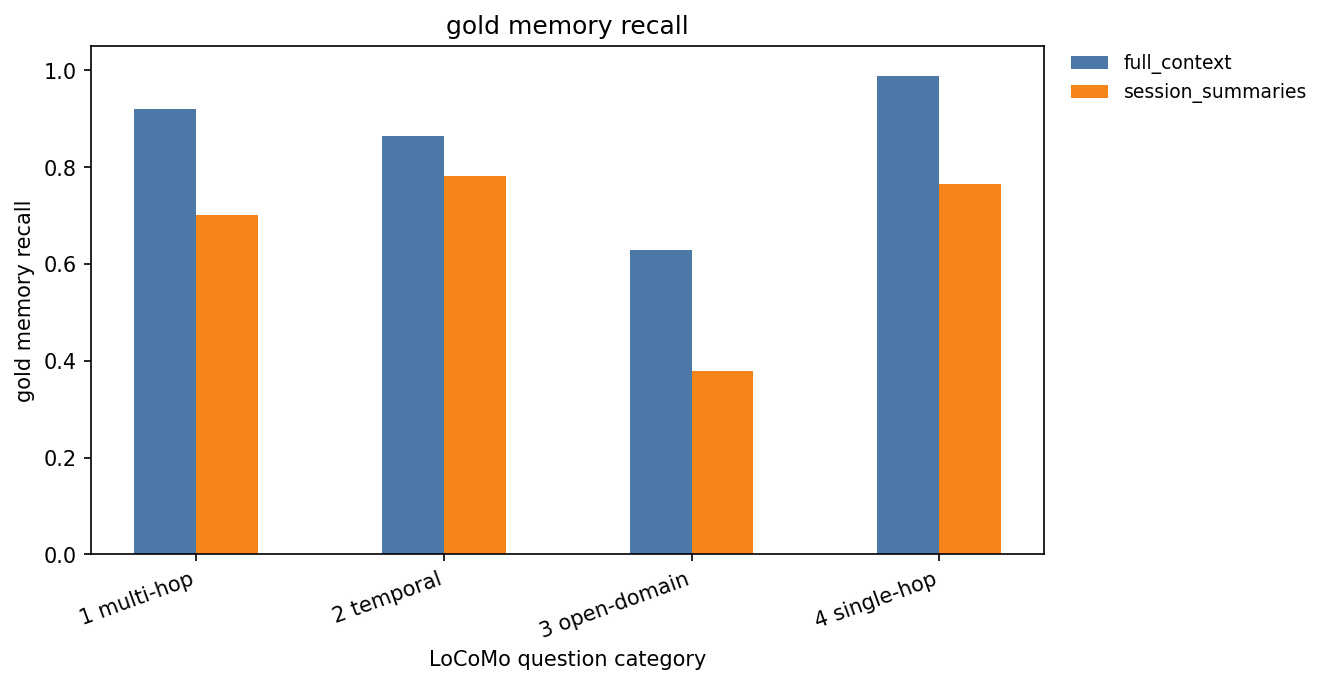

In [5]:
notebook_show(report, only=("gold_token_stages", "gold_token_by_category"), header=False)


## Abstention

Category 5 questions are unanswerable. The LoCoMo score is 1 when the prediction contains `not mentioned` or `no information available`, and 0 otherwise. Calling that an abstention is right as the decision, and the metric only catches those two phrases. `No mention of painting` and `didn't mention` are refusals this table scores as failures.

Adversarial refusal is that phrase on category 5 (n = 446). False refusal is the same phrase on categories 1-4 (n = 1540).

The model refuses more traps than Codex, and it also false-refuses more real questions. The gap is in the summaries, where the memory text is thinner: the model refuses 57 traps and false-refuses 72 answerable questions; persist-off refuses 9 and 15; persist-on refuses 19 and 12. Full context is already near the floor (9, 3, and 5 traps; 4, 2, and 1 false refusals).

Persist-on uses the official phrase more often than persist-off. Several of those new hits are the same refusal rewritten from `no mention` or `didn't mention` into `not mentioned`. A wider refusal family, including those near-misses, does not show fewer false refusals under persist-on. Note writes are rare (38 on full context, 26 on summaries), and only one full-context trap hit had the official phrase only inside a notes block. The table is a phrase-rate comparison. It is not evidence that the note store improved abstention reasoning.


### Adversarial refusal and false refusal

memory_method,prompt_parity_condition,n,adversarial_refusal,adversarial_refusal_n,false_refusal,false_refusal_n
full_context,4o-mini,1986,0.0202,446,0.0026,1540
full_context,4o-mini + Codex (persist off),1986,0.0067,446,0.0013,1540
full_context,4o-mini + Codex (persist on),1986,0.0112,446,0.0006,1540
session_summaries,4o-mini,1986,0.1278,446,0.0468,1540
session_summaries,4o-mini + Codex (persist off),1986,0.0202,446,0.0097,1540
session_summaries,4o-mini + Codex (persist on),1986,0.0426,446,0.0078,1540


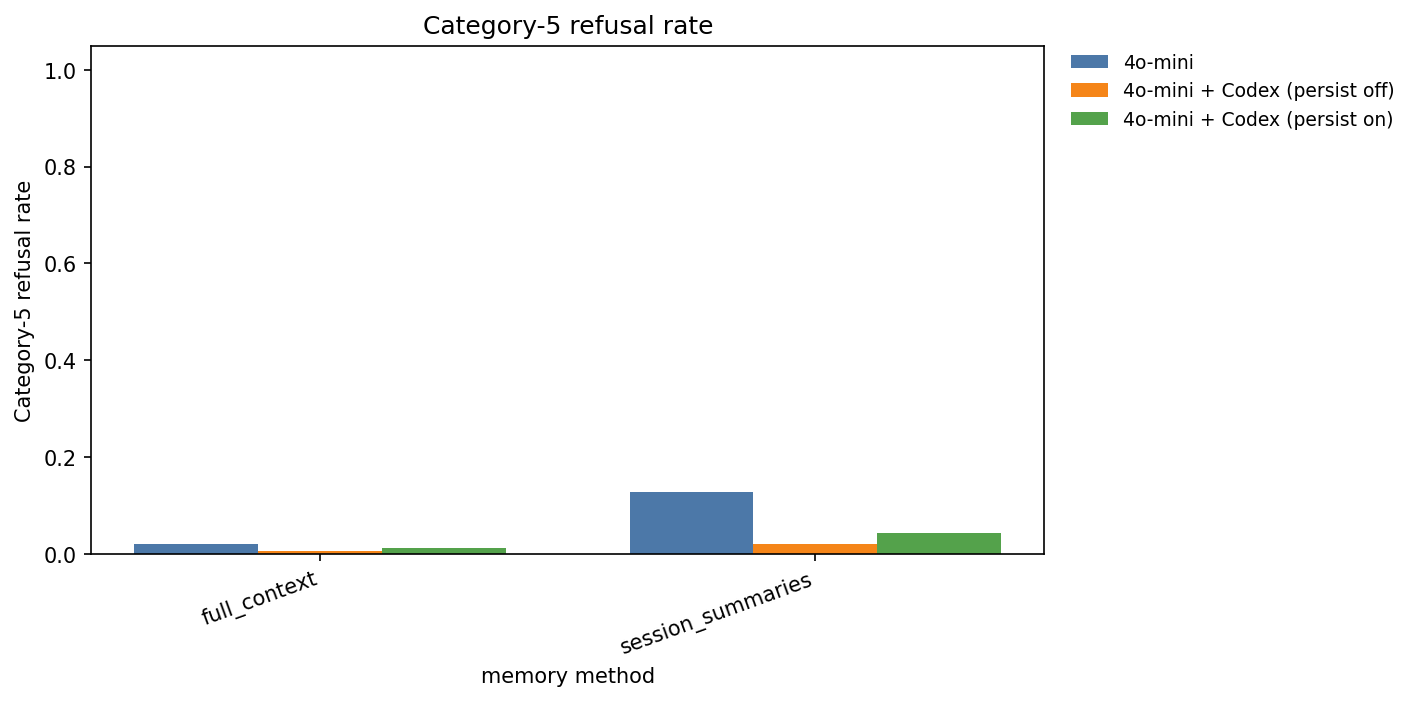

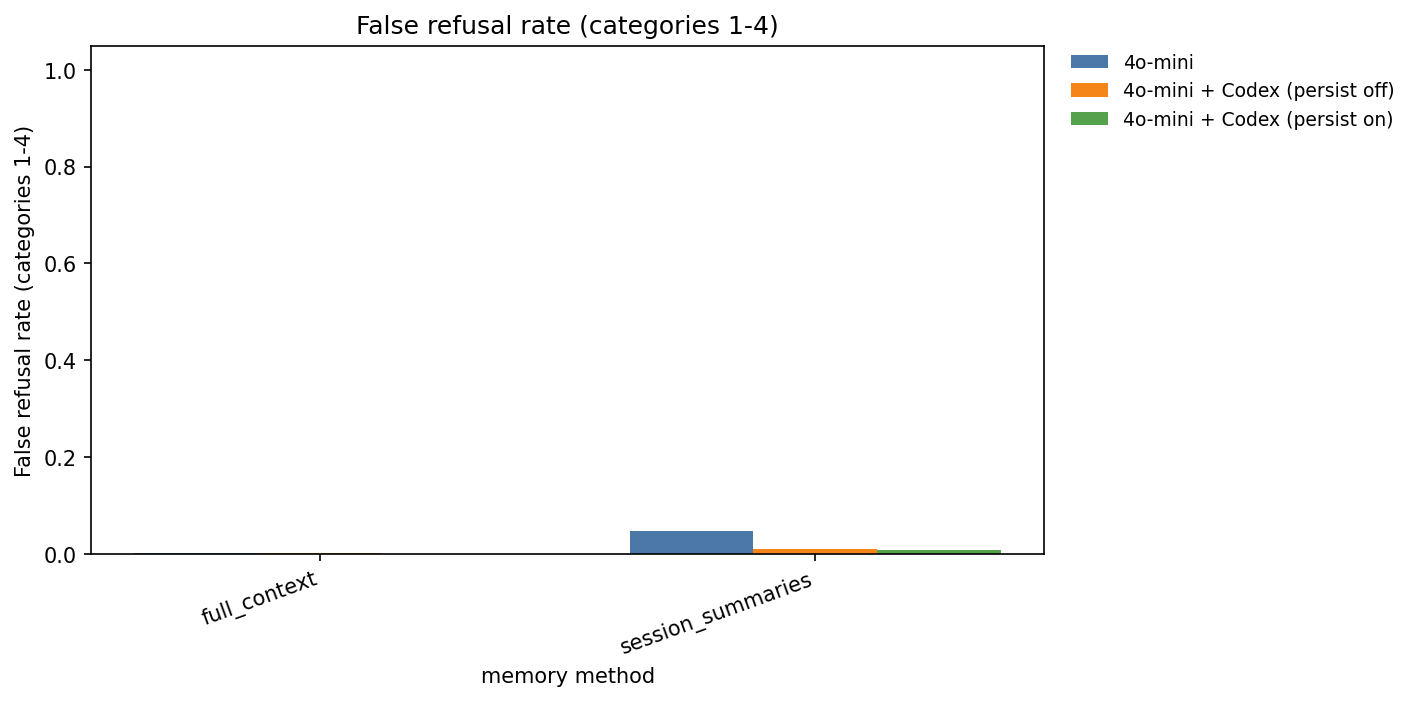

In [6]:
notebook_show(report, only=("adversarial_refusal",), header=False)


## Gaps

These differences were checked against the run packs. They are properties of the answers and the harness, not of a failed job or a mismatched prompt.

| Gap | What the packs show |
|---|---|
| Judge up, F1 down | Same predicted string. Answers are longer. The judge accepts the paraphrase. F1 penalizes the extra tokens. |
| Precision below recall | Overlap with the reference stays near 2 stems. Answer length grows. |
| Persist-off below the model | The reader payload hash matches. The notes footer is absent. Codex writes past the shared 5-6 word line. |
| Memory construction | Memory recall matches across the three readers. Summaries lose gold stems before any reader runs. |
| Notes as the memory | Full-context persist-on wrote notes 38 times and read them 4 times. Summaries wrote 26 and read 32. Later questions are not being answered from a growing store. |
| Notes text inside the score | 112 of 1,986 full-context persist-on answers and 26 summary answers contain a Memory Notes block or `notes.md`. Stripping those blocks moves full-context F1 only from 0.337 to 0.342. |
| Agent loop | 1,986 of 1,986 questions have one `turn.completed`. The 41 persist-on command questions bill a second model call inside that same turn, and that usage is already in the cost mean. |
| Outside tools | Web search, MCP, and harness failures are 0. `sandbox_permissions` is ignored by this Codex CLI. The sandbox that ran was read-only or workspace-write. |
| Model metadata | `gpt-4o-mini` is absent from Codex's bundled catalog, so turns use the unknown-model fallback. Prompts were about 28k tokens. The fallback window is 272k, so it did not clip them. |

The audit table is the tool and write check. `n_web_search` and `n_mcp` stay at 0. `n_write_events` is the note-write count.


### Codex tool and persistence audit

memory_method,agent_persist,n,n_web_search,n_mcp,used_non_workspace_tools,n_write_events,notes_retrieved,notes_bytes,harness_failed_rate
full_context,false,1,0,0,0,0,0,,0
full_context,true,1,0,0,0,0.0191,0.002,268.3087,0
session_summaries,false,1,0,0,0,0,0,,0
session_summaries,true,1,0,0,0,0.0131,0.0161,204.929,0


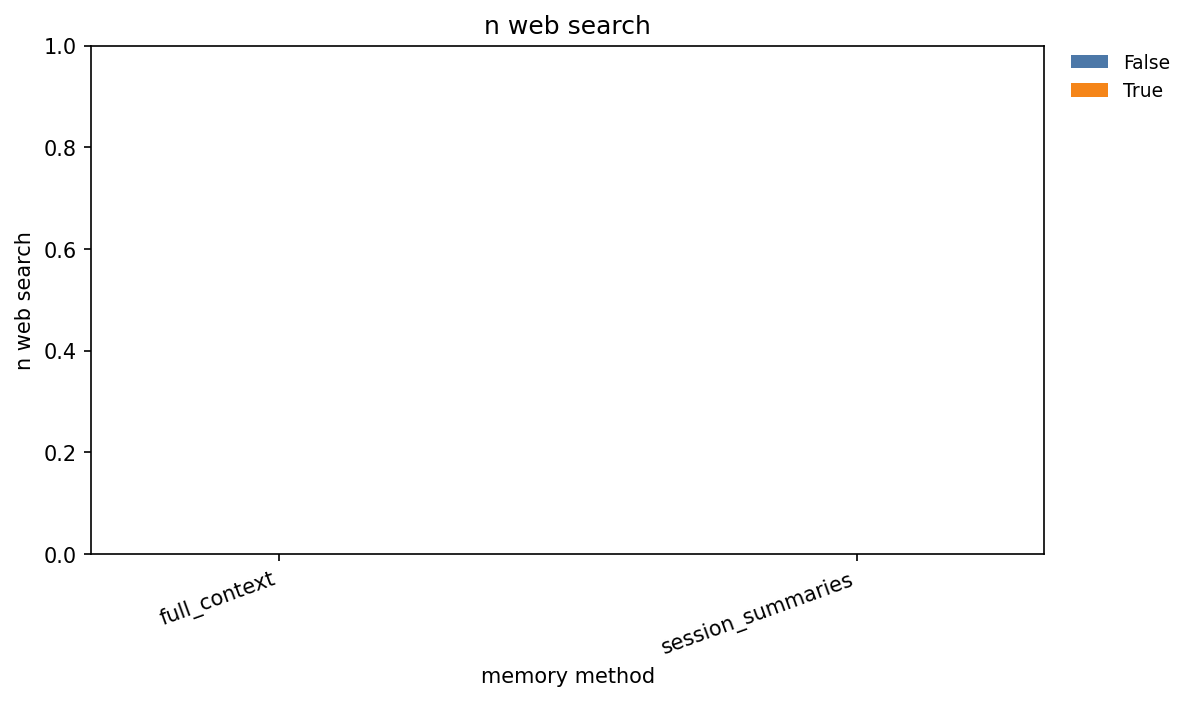

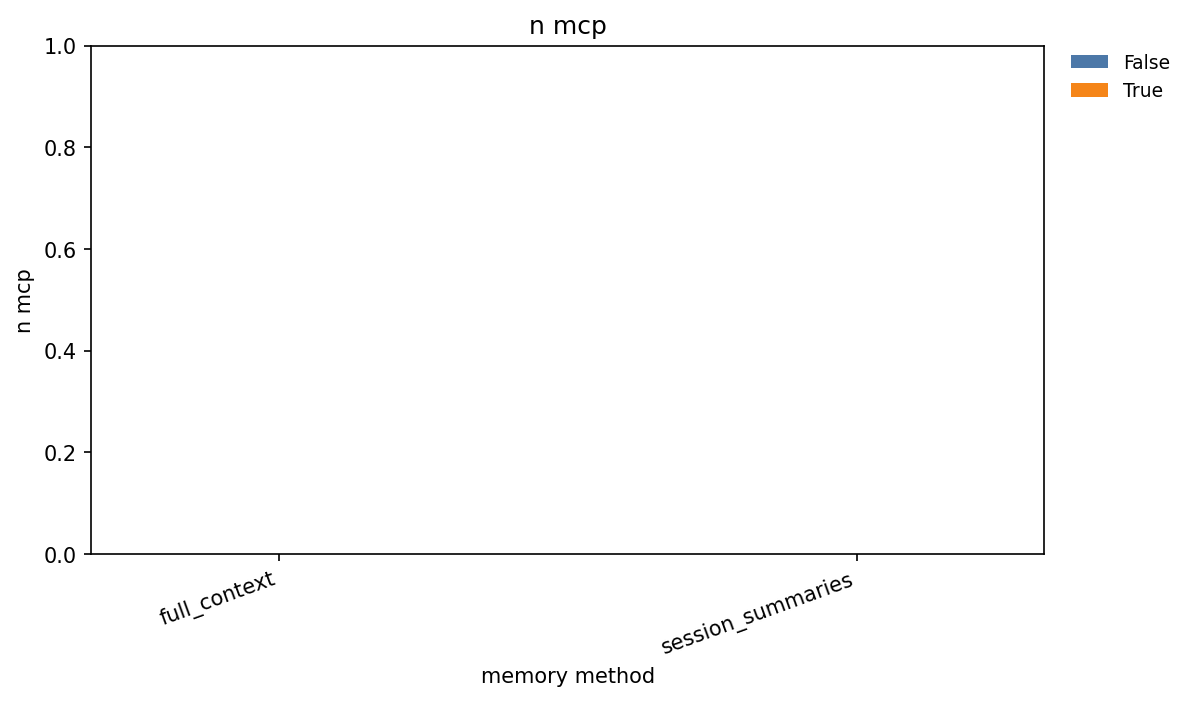

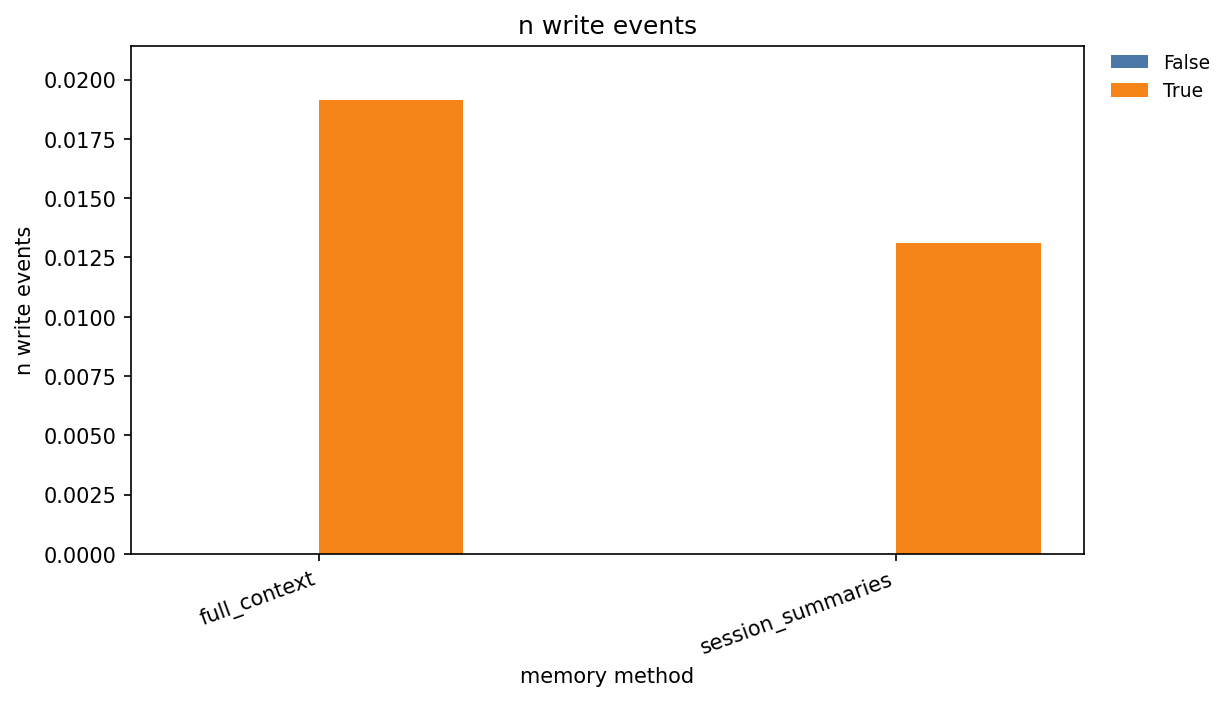

In [7]:
notebook_show(report, only=("codex_audit",), header=False)


## Verification

These rows are in the local collected packs. The packs are gitignored. Line numbers are the `predictions.jsonl` line of that question.

Shared question, three answers, no notes block. Reference: "by carving out some me-time each day for activities like running, reading, or playing the violin."

| Cell | Line | Answer |
|---|---|---|
| Model | [0830e2f8 predictions.jsonl:85](../experiments/locomo-openai-mini-codex-readers-analysis-v2/collected/runs/locomo-openai-mini-codex-readers-analysis-v2-0830e2f8/predictions.jsonl) | By running, reading, and playing violin. |
| Persist-off | [4deb78f9 predictions.jsonl:85](../experiments/locomo-openai-mini-codex-readers-analysis-v2/collected/runs/locomo-openai-mini-codex-readers-analysis-v2-4deb78f9/predictions.jsonl) | Melanie carves out daily "me-time" for activities like running, reading, or playing violin. |
| Persist-on | [47639359 predictions.jsonl:85](../experiments/locomo-openai-mini-codex-readers-analysis-v2/collected/runs/locomo-openai-mini-codex-readers-analysis-v2-47639359/predictions.jsonl) | Melanie prioritizes self-care by carving out "me-time" daily through activities like running, reading, and playing the violin. |

`conv-26-q-84`. Persist-on keeps more of the reference wording and adds words. That is the precision gap without a notes block.

Notes appended onto a correct date. Reference: "7 May 2023".

| Cell | Line | Answer |
|---|---|---|
| Model | [0830e2f8:1](../experiments/locomo-openai-mini-codex-readers-analysis-v2/collected/runs/locomo-openai-mini-codex-readers-analysis-v2-0830e2f8/predictions.jsonl) | 7 May, 2023 |
| Persist-off | [4deb78f9:1](../experiments/locomo-openai-mini-codex-readers-analysis-v2/collected/runs/locomo-openai-mini-codex-readers-analysis-v2-4deb78f9/predictions.jsonl) | Caroline went to the LGBTQ support group on 7 May 2023. |
| Persist-on | [47639359:1](../experiments/locomo-openai-mini-codex-readers-analysis-v2/collected/runs/locomo-openai-mini-codex-readers-analysis-v2-47639359/predictions.jsonl) | The date, then a Memory Notes Update that repeats it. |

`conv-26-q-0`. The fact is in all three answers. F1 falls as the answer grows, and the notes block is an extra penalty on persist-on only.

Instruction text instead of the answer. Reference, category 3: "Yes" before the semicolon.

Persist-on `conv-26-q-64`, [line 65](../experiments/locomo-openai-mini-codex-readers-analysis-v2/collected/runs/locomo-openai-mini-codex-readers-analysis-v2-47639359/predictions.jsonl): "I added to the memory notes that Melanie enjoys classical music..." The model and persist-off both say "Yes, she enjoys classical music." The judge can still mark the long form correct. F1 on the notes sentence is 0. The verdict is the same line in [autorater_verdicts.jsonl](../experiments/locomo-openai-mini-codex-readers-analysis-v2/collected/runs/locomo-openai-mini-codex-readers-analysis-v2-47639359/autorater/autorater_verdicts.jsonl).

Phrase wording, category 5, empty reference. `conv-30-q-82`, line 282.

| Cell | Answer | Official phrase |
|---|---|---|
| Model | The memories do not mention painting. | no |
| Persist-off | No mention of painting. | no |
| Persist-on | Jon's favorite style of painting is not mentioned in the memories. | yes |

Same abstention. Only persist-on matches `not mentioned`. That is why a higher official refusal rate is not, by itself, better abstention reasoning.


## Limitations

- The refusal table counts two substrings. Other abstentions, including `no mention` and `didn't mention`, score as answers.
- Gold stems miss a paraphrase that keeps the fact and changes the word. Answer recall is a lower bound on fact-finding. The judge is the paraphrase check.
- Category 5 has no reference tokens, so retention does not score traps.
- List price ignores cached input, batch discounts, and the judge. Codex token counts include harness wrapping, so they are not the Chat Completions bill for the same string. The recorded usage is one turn per question. It already includes the second model call on the 41 persist-on questions that ran a command.
- Codex has no catalog entry for `gpt-4o-mini`. The unknown-model fallback assumes a 272,000-token window, truncates tool output at 10,000 bytes, and records no reasoning summary. GPT-4o-mini's window is 128,000 tokens. These prompts were about 28,000 tokens, so the window did not clip them. Reasoning tokens are 0 because this model has no reasoning setting, and because the fallback leaves reasoning levels empty.
- Native Codex `strict` is false, so the run is `incomparable` for a shared tool-budget claim. Web search and MCP were off and the audit counts are 0.
- One LoCoMo sample of 10 conversations. The notes store was barely used, so persist-on is mostly the footer instruction.


## Future directions

- Score abstention with a small phrase family (`no mention`, `didn't mention`, `not mentioned`, `no information`) and report that rate next to the official two-phrase score.
- Put the 5-6 word line in the Codex task where the harness cannot bury it, and rerun persist-off. That isolates brevity from the note footer.
- Tell persist-on to return only the answer, and to write notes in `memory/notes.md` rather than in the scored string.
- A FactScore-style pass would judge atomic facts in the answer. LoCoMo uses that for event summaries, not for this QA task. Recall and precision already separate "the reference word is present" from "the answer is mostly those words."


## Discussion

The harness does not receive a different memory. Full-context memory recall is 0.928 for all three readers, and the summaries figure is 0.733 for all three. What changes is the answer string.

Persist-off is the clean comparison: same payload hash, no note footer, no note file. It matches the model's fact-finding and writes longer answers, so precision and F1 fall while the judge stays level. Persist-on finds slightly more of the reference, writes much longer answers, and sometimes appends the note update to the scored text. The judge moves up a little because the meaning is still there. F1 moves down because the extra words are not in the reference. Removing the notes blocks does not close that F1 gap.

The summaries model refuses traps more often and also refuses real questions more often. Codex refuses fewer of both. Persist-on's higher official refusal rate is partly a rewrite into the exact LoCoMo phrase. The note file is too small, and too rarely read, to explain either the length or the refusals.

### Claims the tables support

1. **The three readers see the same memory text.** Evidence: gold-stem memory recall is 0.928 on full context and 0.733 on summaries for the model, persist-off, and persist-on. Model and persist-off also share `reader_payload_sha256`.
2. **Persist-off does not improve fact-finding.** Evidence: full-context answer recall is 0.595 for the model and 0.589 for persist-off. Kept-given-memory is 0.613 and 0.611. Summaries are 0.375 and 0.384.
3. **Persist-on finds only a few more reference stems.** Evidence: full-context answer recall rises from 0.595 to 0.629, and kept-given-memory from 0.613 to 0.655. That is still about two-thirds of the gold stems that were already in the prompt. Token-weighted overlap moves from 1.94 stems to 2.30.
4. **The judge-versus-F1 split is extra words in the answer.** Evidence: full-context judge score is 0.747 / 0.741 / 0.764 while LoCoMo F1 is 0.538 / 0.438 / 0.337. Overlap with the reference stays near 2 stems (1.94 / 2.02 / 2.30) while answer length grows from 3.61 to 5.60 to 10.64 stems (4.1 / 6.4 / 14.1 words). `conv-26-q-84` keeps the self-care fact in a longer sentence and has no notes block.
5. **The persist-off F1 drop is not the notes instruction.** Evidence: persist-off has the same payload as the model, no footer, and no notes file, and full-context F1 is already 0.438 against 0.538. The shared prompt already asks for an answer under 5-6 words. The model averages 4.1 words. Persist-off averages 6.4.
6. **Appended notes are real and too rare to explain the F1 gap.** Evidence: 112 of 1,986 full-context persist-on answers and 26 summary answers contain a Memory Notes block or `notes.md` (`conv-26-q-0`, `conv-26-q-64`). Stripping those blocks moves full-context F1 from 0.337 to 0.342. Full-context Codex wrote notes 38 times and read them 4 times. Summaries wrote 26 and read 32.
7. **Outside tools and job failures do not explain the gap.** Evidence: web search, MCP, and harness failures are 0. The sandbox that ran was read-only or workspace-write. Prompts were about 28,000 tokens, under both the 128,000-token model window and the 272,000-token Codex fallback window.
8. **The cost gap is one longer call plus startup, not a hidden agent loop.** Evidence: 1,986 of 1,986 questions have one `turn.completed`. Persist-off ran one shell command in the whole cell. Full-context p50 is 0.65 s / 2.06 s / 2.25 s. List price is $0.00418 / $0.00526 / $0.00543. The 41 persist-on command questions average about 72,000 input tokens against about 35,000 without a command, and that second call is already inside the $0.00543 mean.
9. **On summaries, Codex refuses fewer traps and makes fewer official false refusals than the model.** Evidence: the model refuses 57 of 446 traps and false-refuses 72 of 1,540 answerable questions. Persist-off is 9 and 15. Persist-on is 19 and 12. Full context is already near the floor (9 / 3 / 5 traps and 4 / 2 / 1 false refusals).
10. **A higher official refusal rate under persist-on is a phrase match, not a shown reasoning gain.** Evidence: `conv-30-q-82` goes from "No mention of painting" (scores 0) to "is not mentioned" (scores 1). The same decision matches the official substring only on persist-on. Note writes are too rare to credit the note store. At most one full-context trap hit had the phrase only inside a notes block.


## Conclusion

With the reader payload held fixed, Codex does improve GPT-4o-mini's fact-finding slightly. Persist-off matches it. Persist-on raises answer recall only from 0.595 to 0.629 on full context, and keeps about two-thirds of the gold stems that were already in the prompt.

The judge-versus-F1 split is answer length. Precision falls because the answer adds stems, from about 3.6 stems for the model to about 5.6 for persist-off and about 10.6 for persist-on, while the overlap with the reference stays near 2 stems. The shared brevity instruction already explains the persist-off gap. The note footer explains the further persist-on gap. The note store does not: writes and reads are rare, and stripping appended notes barely moves F1.

On abstention, Codex refuses fewer traps and makes fewer official false refusals than the model, mainly when the memory is session summaries. Persist-on versus persist-off is a small phrase-wording shift, not a shown gain in abstention reasoning.

On cost, Codex is slower than it is more expensive. One turn per question. Latency about 3.2 times the model. List price about 1.3 times.
